# Diagnóstico por municipio — ¿alcanza un solo modelo para los ocho?

**Proyecto de Aprendizaje Automático (PAA) — UTEC / LIDIA 2026 · Predicción de siniestros viales**

Es el **notebook de diagnóstico del proyecto**: describe la calidad y la estructura temporal de la serie
de **los ocho municipios de Montevideo** (A, B, C, CH, D, E, F, G) y lo usa para contestar la pregunta de
diseño que sigue: **¿un único modelo puede generalizar a todos los municipios, o hay que entrenar más de
uno?**

*Reemplaza a `diagnostico_datos`, `diagnostico_datos_municipio` y `diagnostico_zona_contraste`, retirados de
`main` el 2026-10-05 (siguen en la rama `entregable_2`). Esos notebooks calculaban sobre el período completo,
incluido el test.*

> ### Regla de este notebook: el test no se consulta
>
> El bloque final de 329 días (**2025-02-06 → 2025-12-31**, el 20 % final) es el **futuro** del
> proyecto y se reserva para evaluar el modelo al final. **Este notebook no lo carga en memoria ni
> calcula nada con él, en ninguna sección**: las filas posteriores a 2025-02-05 se descartan en el mismo
> paso en que se leen los archivos, antes de cualquier cálculo, y un `assert` verifica que no queda
> ninguna. Todo lo que sigue (descripción, pruebas y comparación predictiva) usa **sólo el bloque de
> desarrollo**: 1.316 días, 2021-07-01 → 2025-02-05.
>
> *Consecuencia:* las cifras de este notebook **no son comparables** con las de los diagnósticos de C y A
> ni con las de los diagnósticos que reemplaza (rama `entregable_2`), que usan el período completo. Por la misma razón no se las
> cruza con `assert` contra esos notebooks (hacerlo exigiría calcular sobre el test).

**Qué responde este notebook**

| Pregunta | Sección |
| --- | --- |
| ¿Los ocho paneles tienen la misma calidad (cobertura, ceros, dispersión, atípicos, geocodificación)? | 2 |
| ¿La tendencia, el calendario semanal y el patrón anual son los mismos en los ocho? | 3 y 4 |
| ¿Tienen la misma memoria temporal, y conviene transformar el objetivo igual en todos? | 5 |
| ¿Los municipios se mueven juntos día a día? | 6 |
| ¿Las diferencias entre municipios son lo bastante grandes como para justificar modelos separados? | 7 |
| ¿Qué bloque de variables (calendario, tasa del municipio, lluvia) aporta más fuera de muestra? | 7.5 |
| ¿Qué faltantes tiene la fuente, cuánto cuesta el corte de la pandemia y cómo es la cobertura temporal y territorial? | 2.4 a 2.7 |

**Cómo se decide (sección 7).** Una diferencia puede ser *estadísticamente detectable* y a la vez *inútil
para predecir*. Por eso la decisión no se apoya en las pruebas de hipótesis sino en una comparación
predictiva: seis variantes de un modelo mínimo (nivel × calendario), ajustadas sólo con el pasado y
evaluadas en ventanas posteriores con desvianza de Poisson, bajo un criterio fijado **antes** de mirar los
resultados.

**Qué NO hace.** No repite el resto de la auditoría de la **fuente cruda** (duplicados, formato de fecha,
asignación a municipios, clima): la documenta el ETL (`preparacion_montevideo.ipynb`,
`experiments/etl_montevideo/`). **Tampoco repite la verificación cruzada independiente con el ETL** que hacía el
diagnóstico retirado (decisión del equipo). No elige el modelo final ni evalúa familias de modelos: usa
deliberadamente un modelo mínimo para medir **estructura**, no desempeño.

**Fuentes.** `data/processed/panel_diario_montevideo.csv` (panel del ETL) y
`data/processed/siniestros_montevideo.csv` (eventos con coordenadas); y, sólo para las secciones 2.4, 2.5 y 2.7,
el archivo crudo `data/raw/uru_siniestros_unificado.csv` y la capa `data/raw/municipios_montevideo.geojson`.
**En todos los casos las filas posteriores a 2025-02-05 se descartan en el mismo paso en que se leen**, antes de
cualquier cálculo.

**Artefactos.** Tablas y figuras en `experiments/diagnostico_municipios/`.

## 0. Configuración y trazabilidad

In [1]:
import hashlib
import importlib.metadata as md_meta
import platform
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import holidays
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from scipy import stats as sps
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)  # KPSS acota el p-valor a [0,01; 0,10] y lo avisa

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir())
DIR_PROCESADO = RAIZ / "data" / "processed"
RUTA_PANEL = DIR_PROCESADO / "panel_diario_montevideo.csv"
RUTA_EVENTOS = DIR_PROCESADO / "siniestros_montevideo.csv"
RUTA_CRUDO = RAIZ / "data" / "raw" / "uru_siniestros_unificado.csv"
RUTA_CAPA = RAIZ / "data" / "raw" / "municipios_montevideo.geojson"

DIR_SALIDA = RAIZ / "experiments" / "diagnostico_municipios"
DIR_TABLAS = DIR_SALIDA / "tablas"
DIR_FIGURAS = DIR_SALIDA / "figuras"
for d in (DIR_TABLAS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# Alcance heredado del ETL (preparacion_montevideo.ipynb) y de la decisión de recorte del diagnóstico previo (retirado de main).
FECHA_INICIO = "2021-07-01"
FECHA_FIN_PERIODO = "2025-12-31"   # fin del calendario del proyecto (constante de calendario, no un dato)
CATEGORIAS_FERIADO = ("public", "bank")
ORDEN = ["C", "B", "D", "A", "F", "G", "E", "CH"]   # de más a menos siniestros (resumen_diagnostico_datos.md §4.2)

# Particiones: las mismas de linea_base.ipynb (80 % desarrollo / 20 % bloque final = TEST; dentro del
# desarrollo, 75 % de ajuste inicial). El bloque final es el futuro del proyecto: este notebook NO lo
# carga en memoria ni calcula nada con él, en ninguna sección (se descarta al leer los archivos).
FRAC_DESARROLLO = 0.80
FRAC_AJUSTE = 0.75
SEMILLA = 20260910          # la de linea_base.ipynb
N_REMUESTRAS = 2000         # remuestreos del bootstrap por bloques
LARGO_BLOQUE = 7            # días por bloque (semana)
UMBRAL_DESV_REL = 0.01      # regla fijada ANTES de ejecutar la sección 7.2 (ver su texto)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})
COLORES = dict(zip(ORDEN, ["#22546e", "#c0542f", "#4a8c6a", "#8a5a9c", "#d19a2a",
                           "#3f8fbf", "#7a7a7a", "#a63d5e"]))


def guardar_tabla(tabla, nombre, indice=False):
    destino = DIR_TABLAS / f"{nombre}.csv"
    tabla.to_csv(destino, index=indice, encoding="utf-8")
    print(f"[tabla]  {destino.relative_to(RAIZ)}")
    display(tabla)


def guardar_figura(fig, nombre):
    destino = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(destino)
    print(f"[figura] {destino.relative_to(RAIZ)}")

Se parte del panel que dejó el ETL, ya verificado de forma independiente
(`resumen_preparacion_montevideo.md` §8). Se registra la procedencia de los dos archivos: el `sha256`
identifica el archivo completo (se calcula sobre los bytes, no se leen valores).

In [2]:
FUENTES = [("panel_diario_montevideo", RUTA_PANEL), ("siniestros_montevideo", RUTA_EVENTOS),
           ("uru_siniestros_unificado (crudo)", RUTA_CRUDO), ("municipios_montevideo (capa)", RUTA_CAPA)]
filas = []
for nombre, ruta in FUENTES:
    if not ruta.exists():
        raise FileNotFoundError(f"falta {ruta.relative_to(RAIZ)}: ver el README (datos crudos) o ejecutar preparacion_montevideo.ipynb")
    filas.append((nombre, str(ruta.relative_to(RAIZ)), f"{ruta.stat().st_size / 1e6:.2f} MB",
                  hashlib.sha256(ruta.read_bytes()).hexdigest(),   # identifica el archivo; no se leen valores
                  datetime.fromtimestamp(ruta.stat().st_mtime).strftime("%Y-%m-%d %H:%M")))
procedencia = pd.DataFrame(filas, columns=["fuente", "archivo", "tamaño", "sha256", "modificado"])

paquetes = ["pandas", "numpy", "statsmodels", "scipy", "matplotlib", "holidays"]
entorno = pd.DataFrame(
    [("ejecutado", datetime.now(timezone.utc).astimezone().strftime("%Y-%m-%d %H:%M")),
     ("python", f"{sys.version.split()[0]} · {platform.system()} {platform.release()}"),
     ("semilla", SEMILLA)]
    + [(p, md_meta.version(p)) for p in paquetes], columns=["clave", "valor"])
guardar_tabla(procedencia, "00_procedencia")
guardar_tabla(entorno, "00b_entorno")

[tabla]  experiments\diagnostico_municipios\tablas\00_procedencia.csv


,fuente,archivo,tamaño,sha256,modificado
0,panel_diario_montevideo,data\processed\panel_diario_montevideo.csv,1.00 MB,82467fc87b5d2bceb24ec6f3c5072e1b7cf9e75507b1d5...,2026-09-07 14:30
1,siniestros_montevideo,data\processed\siniestros_montevideo.csv,2.23 MB,b62851732c2ad9740c24cf3128ba265c074a26a40a446b...,2026-09-07 14:30
2,uru_siniestros_unificado (crudo),data\raw\uru_siniestros_unificado.csv,26.19 MB,48a8a7e8f06ed8aa1d138b9921995d81a2c86cb3858354...,2026-08-24 11:21
3,municipios_montevideo (capa),data\raw\municipios_montevideo.geojson,2.87 MB,ed0ba13e53b08f1e35eead16ffdef16d57e518aff30c7c...,2026-09-07 13:36


[tabla]  experiments\diagnostico_municipios\tablas\00b_entorno.csv


,clave,valor
0,ejecutado,2026-10-08 09:41
1,python,3.13.2 · Windows 10
2,semilla,20260910
3,pandas,2.3.3
4,numpy,2.5.2
5,statsmodels,0.14.6
6,scipy,1.18.1
7,matplotlib,3.11.1
8,holidays,0.103


## 1. Carga, verificación y particiones

### 1.1 Carga del panel de desarrollo y verificación de integridad

El límite del desarrollo (80 % de los 1.645 días del calendario del proyecto: **2025-02-05**) sale de las
fechas, no de los datos. Se leen los archivos, se descarta de inmediato todo lo posterior y se comprueba
que (i) están los ocho municipios, (ii) no hay huecos de calendario ni pares repetidos, (iii) el feriado
que calcula este notebook coincide con el `tipo_dia` del ETL, (iv) el clima es una única serie para el
departamento y (v) no quedó ninguna fila posterior al último día de desarrollo.

In [3]:
# Calendario del proyecto y límite del desarrollo: salen de las fechas, no de los datos.
DIAS_TOTAL = pd.date_range(FECHA_INICIO, FECHA_FIN_PERIODO, freq="D")
N_TOTAL = len(DIAS_TOTAL)
N_DES = int(round(FRAC_DESARROLLO * N_TOTAL))
ULTIMO_DIA_DES = DIAS_TOTAL[N_DES - 1]
PRIMER_DIA_TEST = DIAS_TOTAL[N_DES]

# Las filas posteriores a ULTIMO_DIA_DES (test) se descartan en el mismo paso de lectura, antes de
# cualquier cálculo, y no se vuelven a usar.
panel = pd.read_csv(RUTA_PANEL, encoding="utf-8")
panel["fecha"] = pd.to_datetime(panel["fecha"], format="%Y-%m-%d")   # ISO: el formato se fija, no se adivina
panel = panel[panel["fecha"] <= ULTIMO_DIA_DES].copy()
panel["mun"] = panel["zona_id"].str.replace("MUNICIPIO ", "", regex=False)

assert panel["fecha"].max() == ULTIMO_DIA_DES, "el panel no llega al último día de desarrollo"
assert sorted(panel["mun"].unique()) == sorted(ORDEN), panel["mun"].unique()
assert not panel.duplicated(["fecha", "mun"]).any(), "hay pares (fecha, municipio) repetidos"

y = panel.pivot(index="fecha", columns="mun", values="n_siniestros")[ORDEN]
DIAS = pd.date_range(FECHA_INICIO, ULTIMO_DIA_DES, freq="D")
assert y.index.equals(DIAS), "el panel tiene huecos de calendario o no empieza en FECHA_INICIO"
assert not y.isna().any().any(), "hay celdas vacías en la matriz fecha × municipio"
N = len(y)
assert N == N_DES

# Calendario: día de la semana, con el feriado como grupo aparte (mismo criterio que el diagnóstico)
DIAS_ES = {0: "lunes", 1: "martes", 2: "miércoles", 3: "jueves", 4: "viernes", 5: "sábado", 6: "domingo"}
ORDEN_SEMANA = list(DIAS_ES.values())
fer = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1), categories=CATEGORIAS_FERIADO)
es_fer = pd.Series([d.date() in fer for d in DIAS], index=DIAS)
grupo = pd.Series(DIAS.dayofweek.map(DIAS_ES), index=DIAS).where(~es_fer, "feriado")
GRUPOS = ORDEN_SEMANA + ["feriado"]

tipo_dia = panel.drop_duplicates("fecha").set_index("fecha")["tipo_dia"].reindex(DIAS)
clima_unico = bool((panel.groupby("fecha")[["temp_media", "precipitacion_mm", "llovio"]].nunique() == 1).all().all())
llovio = panel.drop_duplicates("fecha").set_index("fecha")["llovio"].reindex(DIAS)

# Verificaciones de integridad que NO requieren mirar el test (las cifras de referencia de los otros
# notebooks son del período completo y por eso no se comparan acá).
verif = pd.DataFrame([
    ("municipios presentes", 8, panel["mun"].nunique()),
    ("filas del panel de desarrollo", N_DES * 8, len(panel)),
    ("días de calendario sin hueco", N_DES, int(y.index.equals(DIAS)) * N_DES),
    ("pares (fecha, municipio) repetidos", 0, int(panel.duplicated(["fecha", "mun"]).sum())),
    ("feriados que difieren de tipo_dia del ETL", 0, int(((tipo_dia == "feriado") != es_fer).sum())),
    ("el clima difiere entre municipios (1 = sí)", 0, int(not clima_unico)),
    ("filas posteriores al último día de desarrollo", 0, int((panel["fecha"] > ULTIMO_DIA_DES).sum())),
], columns=["comprobación", "esperado", "obtenido"])
verif["resultado"] = np.where(verif["esperado"] == verif["obtenido"], "coincide", "DIFIERE")
guardar_tabla(verif, "01_verificacion_integridad")
assert (verif["resultado"] == "coincide").all(), "falló una comprobación de integridad"
print(f"desarrollo: {DIAS[0]:%Y-%m-%d} -> {DIAS[-1]:%Y-%m-%d} ({N:,} días × {len(ORDEN)} municipios). "
      f"Reservado (no cargado): desde {PRIMER_DIA_TEST:%Y-%m-%d}.")

[tabla]  experiments\diagnostico_municipios\tablas\01_verificacion_integridad.csv


,comprobación,esperado,obtenido,resultado
0,municipios presentes,8,8,coincide
1,filas del panel de desarrollo,10528,10528,coincide
2,días de calendario sin hueco,1316,1316,coincide
3,"pares (fecha, municipio) repetidos",0,0,coincide
4,feriados que difieren de tipo_dia del ETL,0,0,coincide
5,el clima difiere entre municipios (1 = sí),0,0,coincide
6,filas posteriores al último día de desarrollo,0,0,coincide


desarrollo: 2021-07-01 -> 2025-02-05 (1,316 días × 8 municipios). Reservado (no cargado): desde 2025-02-06.


**Evidencia (`01_verificacion_integridad`):** las siete comprobaciones coinciden: 8 municipios, 10.528
filas (1.316 días × 8), sin huecos ni repetidos, feriados iguales a los del ETL y **cero filas posteriores
a 2025-02-05**. El clima es una sola serie compartida por los ocho, así que **ninguna variable
meteorológica puede distinguir un municipio de otro**: toda la diferencia entre municipios tiene que venir
de otra parte.

*No se compara con las cifras del período completo* (36.612 siniestros, totales por municipio, etc.): para
hacerlo habría que sumar sobre el test.

### 1.2 Particiones y qué secciones usan qué

Las de [`linea_base.ipynb`](linea_base.ipynb): 80 % desarrollo / 20 % bloque final, y dentro del desarrollo 75 %
de ajuste inicial (**entrenamiento inicial**: 987 días) y 25 % de **validación** (329 días). **El bloque final (test)
figura en la tabla sólo como referencia de calendario: no se carga.**

**Criterio del equipo, confirmado con el docente (2026-10-08): la ventana de validación SÍ puede usarse en los
diagnósticos; sólo el test queda vedado.** Por eso todas las secciones usan el desarrollo (entrenamiento inicial +
validación). Las que orientan decisiones de modelado se contrastan además, en 7.6, con sólo el entrenamiento: es un
**chequeo de estabilidad entre ventanas, no un requisito**.

| Tipo | Secciones | Datos |
| --- | --- | --- |
| **Descriptivas** | 1, 2 (todas), 4.3, 6 | todo el desarrollo |
| **Caracterizan y orientan decisiones** | 3 (tendencia), 4.1 y 4.2 (calendario), 5.1 y 5.2 (memoria, transformación), 7.1 y 7.1b (homogeneidad) | todo el desarrollo; contrastadas con sólo el entrenamiento en 7.6 |
| **Respetan la cronología por construcción** | 5.3 (sólo entrenamiento), 7.2 a 7.5 (ajuste → validación, dos pliegues) | ajuste y validación separados |

In [4]:
N_AJ = int(round(FRAC_AJUSTE * N_DES))
N_VAL = N_DES - N_AJ
N_FIN = N_TOTAL - N_DES
bloques = pd.DataFrame([
    ("ajuste inicial", N_AJ, DIAS[0], DIAS[N_AJ - 1], "cargado"),
    ("validación", N_VAL, DIAS[N_AJ], DIAS[N_DES - 1], "cargado"),
    ("bloque final = TEST (reservado)", N_FIN, PRIMER_DIA_TEST, DIAS_TOTAL[-1], "NO cargado, NO consultado"),
], columns=["bloque", "días", "primer_día", "último_día", "estado en este notebook"])
guardar_tabla(bloques, "02_particiones")
assert (N_AJ, N_VAL, N_FIN) == (987, 329, 329), "la partición no coincide con la de linea_base.ipynb"

[tabla]  experiments\diagnostico_municipios\tablas\02_particiones.csv


,bloque,días,primer_día,último_día,estado en este notebook
0,ajuste inicial,987,2021-07-01,2024-03-13,cargado
1,validación,329,2024-03-14,2025-02-05,cargado
2,bloque final = TEST (reservado),329,2025-02-06,2025-12-31,"NO cargado, NO consultado"


## 2. Calidad de la serie por municipio

### 2.1 Resumen por municipio

Cobertura, nivel, dispersión, ceros y estabilidad mensual. Se agrega la fracción de ceros que
produciría un Poisson con la misma media (`e^-media`): es la comparación que dice si hay **exceso de
ceros** en cada municipio, no sólo muchos ceros.

In [5]:
def racha_maxima_ceros(s):
    bloque = (s != 0).cumsum()
    return int((s == 0).groupby(bloque).sum().max())

mensual = y.groupby([y.index.year, y.index.month]).mean()
_dias_mes = y.groupby([y.index.year, y.index.month]).size()
_dias_cal = pd.Series([pd.Period(f"{a}-{m:02d}").days_in_month for a, m in mensual.index], index=mensual.index)
mensual = mensual[_dias_mes == _dias_cal]   # sólo meses completos (febrero de 2025 queda a medias en el desarrollo)
filas = []
for m in ORDEN:
    s = y[m]
    media, var = s.mean(), s.var(ddof=0)
    idx_mes = mensual[m] / media
    a_min, m_min = idx_mes.idxmin()
    a_max, m_max = idx_mes.idxmax()
    filas.append({
        "municipio": m,
        "siniestros": int(s.sum()),
        "% del total": round(100 * s.sum() / y.values.sum(), 2),
        "media diaria": round(media, 4),
        "varianza (ddof=0)": round(var, 4),
        "dispersión var/media": round(var / media, 4),
        "días en cero": int((s == 0).sum()),
        "% días en cero": round(100 * (s == 0).mean(), 2),
        "% ceros esperados bajo Poisson (e^-media)": round(100 * np.exp(-media), 2),
        "racha máx. de ceros": racha_maxima_ceros(s),
        "mediana": float(s.median()),
        "máximo": int(s.max()),
        "mes más bajo (÷ media)": f"{a_min}-{m_min:02d} ({idx_mes.min():.2f})",
        "mes más alto (÷ media)": f"{a_max}-{m_max:02d} ({idx_mes.max():.2f})",
    })
resumen = pd.DataFrame(filas)
guardar_tabla(resumen, "03_resumen_por_municipio")

[tabla]  experiments\diagnostico_municipios\tablas\03_resumen_por_municipio.csv


,municipio,siniestros,% del total,media diaria,varianza (ddof=0),dispersión var/media,días en cero,% días en cero,% ceros esperados bajo Poisson (e^-media),racha máx. de ceros,mediana,máximo,mes más bajo (÷ media),mes más alto (÷ media)
0,C,4508,15.80,3.4255,4.4238,1.2914,70,5.32,3.25,2,3.0,13,2022-01 (0.66),2024-10 (1.30)
1,B,4218,14.78,3.2052,3.7087,1.1571,72,5.47,4.06,3,3.0,12,2022-01 (0.66),2022-11 (1.25)
2,D,4141,14.51,3.1467,3.6282,1.1530,63,4.79,4.30,2,3.0,12,2021-09 (0.72),2024-06 (1.26)
3,A,3879,13.59,2.9476,3.3430,1.1342,87,6.61,5.25,3,3.0,10,2021-07 (0.71),2024-11 (1.31)
4,F,3472,12.17,2.6383,2.8190,1.0685,98,7.45,7.15,2,2.0,9,2022-01 (0.60),2024-07 (1.32)
5,G,2905,10.18,2.2074,2.3833,1.0796,176,13.37,11.00,3,2.0,8,2022-02 (0.61),2024-05 (1.36)
6,E,2780,9.74,2.1125,2.6758,1.2667,200,15.20,12.09,4,2.0,11,2024-01 (0.57),2021-11 (1.31)
7,CH,2632,9.22,2.0000,2.4271,1.2135,217,16.49,13.53,4,2.0,9,2022-01 (0.58),2021-12 (1.29)


**Evidencia (tabla `03_resumen_por_municipio`, sobre el desarrollo):**

- **Cobertura completa:** 1.316 días en cada municipio, sin huecos; la racha más larga de días
  consecutivos en cero es de **2 a 4**, así que no hay apagones de registro.
- **Nivel:** la media diaria va de **2,00 (CH) a 3,43 (C)**, razón 1,71×; el municipio más activo
  concentra 15,80 % de los siniestros y el menos activo 9,22 %.
- **Dispersión:** var/media entre **1,069 (F) y 1,291 (C)**: en los ocho es mayor que 1 (sobredispersión
  leve), en ninguno es extrema. C, E y CH (1,29; 1,27; 1,21) son los más dispersos.
- **Ceros:** del **4,79 % (D)** al **16,49 % (CH)**. G, E y CH superan el 13 %. Contra lo que daría un
  Poisson con su media (`e^-media`), el exceso es de **+0,30 puntos (F) a +3,11 (E)**.
- **Mes más bajo:** enero en C, B, F, CH (2022-01) y E (2024-01); en **A (2021-07)** y **D (2021-09)**
  cae al inicio de la serie, y en G es 2022-02. (Sólo se consideran meses completos.)

**Inferencia del equipo:** los ocho son la misma clase de problema —conteo diario de media baja con
sobredispersión leve— y **no hay un municipio con un panel de otra naturaleza** (ni ceros estructurales ni
huecos). El mayor porcentaje de ceros de CH, E y G se explica casi todo por su media más baja: no hay
evidencia para un tratamiento *zero-inflated* en ninguno. Que el mes más bajo de A y D esté en el arranque
de la serie es una **observación, no un hallazgo**: podría ser un resto de la recuperación pospandemia que
el corte del 2021-07-01 no eliminó del todo en esos dos municipios, pero no se investigó.

### 2.2 Concentración geográfica de los eventos

Calidad de la geocodificación vista desde las coordenadas: cuántos eventos comparten exactamente la
misma coordenada. Una concentración alta sugiere que el geocodificador "ajusta" los puntos a un
conjunto reducido de ubicaciones (esquinas, direcciones). No afecta el conteo por municipio, que
depende del polígono, pero sí limitaría una zonificación más fina.

In [6]:
ev = pd.read_csv(RUTA_EVENTOS, encoding="utf-8")
ev = ev[pd.to_datetime(ev["fecha"], format="%Y-%m-%d") <= ULTIMO_DIA_DES].copy()   # el test se descarta al leer
ev["mun"] = ev["zona_id"].str.replace("MUNICIPIO ", "", regex=False)
cuenta_ev = ev.groupby("mun").size().reindex(ORDEN)
assert (cuenta_ev.values == y.sum().values).all(), "los eventos no suman lo mismo que el panel"

ev["coord"] = ev["coord_x"].astype(str) + "_" + ev["coord_y"].astype(str)
filas = []
for m in ORDEN:
    e = ev.loc[ev["mun"] == m, "coord"]
    c = e.value_counts()
    filas.append({
        "municipio": m, "eventos": len(e), "coordenadas distintas": int(c.size),
        "eventos por coordenada": round(len(e) / c.size, 2),
        "% eventos en coordenada repetida": round(100 * c[c > 1].sum() / len(e), 2),
        "% en la coordenada más frecuente": round(100 * c.iloc[0] / len(e), 2),
        "% en las 10 más frecuentes": round(100 * c.iloc[:10].sum() / len(e), 2),
    })
geo = pd.DataFrame(filas)
guardar_tabla(geo, "04_concentracion_geografica_eventos")

[tabla]  experiments\diagnostico_municipios\tablas\04_concentracion_geografica_eventos.csv


,municipio,eventos,coordenadas distintas,eventos por coordenada,% eventos en coordenada repetida,% en la coordenada más frecuente,% en las 10 más frecuentes
0,C,4508,943,4.78,92.61,1.77,9.94
1,B,4218,871,4.84,95.31,0.81,5.95
2,D,4141,907,4.57,91.69,1.26,9.35
3,A,3879,1244,3.12,83.17,1.73,8.58
4,F,3472,871,3.99,89.89,2.04,9.65
5,G,2905,897,3.24,84.78,1.34,9.43
6,E,2780,724,3.84,90.36,1.29,9.71
7,CH,2632,633,4.16,92.48,1.44,10.03


**Evidencia (tabla `04_concentracion_geografica_eventos`):** en los ocho, entre el **83,2 % (A)** y el
**95,3 % (B)** de los eventos cae en una coordenada que se repite al menos una vez; hay entre 3,1 y 4,8
eventos por coordenada distinta. **A es el municipio con menos repetición** (1.244 coordenadas distintas
para 3.879 eventos) y B el que más (871 para 4.218). Ninguna coordenada concentra más del 2,1 % de los
eventos de su municipio.

**Inferencia / hipótesis (no verificada):** la resolución de la geocodificación no es idéntica entre
municipios (A parece menos "ajustado"). Con municipios como zonas esto es irrelevante para el objetivo;
**sí sería relevante si más adelante se subdividieran**, porque la calidad posicional no sería homogénea.
No se investigó el origen.

### 2.3 Días atípicos por municipio

Criterio de Tukey (1,5·IQR) aplicado **dentro de cada grupo de calendario** (lunes … domingo, feriado) y
por municipio —el criterio por grupo de calendario del diagnóstico previo (retirado de `main`)—. Es un
control de calidad, no una regla de limpieza: no se elimina ni corrige ningún día.

In [7]:
filas = []
for m in ORDEN:
    s = y[m]
    fuera = pd.Series(False, index=s.index)
    for g in GRUPOS:
        v = s[grupo == g]
        q1, q3 = v.quantile([0.25, 0.75])
        iqr = q3 - q1
        fuera.loc[v.index] = (v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)
    alto = fuera & (s > s.groupby(grupo).transform("median"))
    filas.append({
        "municipio": m, "atípicos en su grupo de calendario": int(fuera.sum()),
        "% de días": round(100 * fuera.mean(), 2), "de ellos, por arriba": int(alto.sum()),
        "de ellos, con 5 o menos siniestros": int((s[fuera] <= 5).sum()),
        "máximo diario": int(s.max()), "fecha del máximo": f"{s.idxmax():%Y-%m-%d}",
        "atípicos desde 2024": int(fuera[fuera.index >= "2024-01-01"].sum()),
    })
atipicos = pd.DataFrame(filas)
guardar_tabla(atipicos, "05_atipicos_por_municipio")

[tabla]  experiments\diagnostico_municipios\tablas\05_atipicos_por_municipio.csv


,municipio,atípicos en su grupo de calendario,% de días,"de ellos, por arriba","de ellos, con 5 o menos siniestros",máximo diario,fecha del máximo,atípicos desde 2024
0,C,16,1.22,16,0,13,2022-11-16,9
1,B,11,0.84,11,0,12,2022-04-29,1
2,D,33,2.51,33,0,12,2023-02-15,8
3,A,19,1.44,19,0,10,2021-11-22,10
4,F,16,1.22,16,0,9,2022-07-22,9
5,G,35,2.66,35,18,8,2024-03-06,12
6,E,9,0.68,9,0,11,2024-04-16,4
7,CH,35,2.66,35,15,9,2021-10-21,10


**Evidencia (tabla `05_atipicos_por_municipio`):** entre **9 (E)** y **35 (G y CH)** días atípicos por
municipio (0,68 % a 2,66 %), **todos por arriba**; ninguno hacia abajo. El máximo diario va de 8 (G) a 13
(C). Desde 2024-01-01 (el 31 % de los días del desarrollo) caen **9 de 16 atípicos en C, 10 de 19 en A y 9
de 16 en F** (53 % a 56 %), pero sólo **1 de 11 en B**.

G y CH tienen el mayor conteo, pero **18 de los 35 de G y 15 de los 35 de CH tienen 5 o menos siniestros**:
en municipios de media ≈ 2, con grupos de calendario de rango intercuartílico muy corto, la valla de Tukey
queda tan baja que marca días de 4 y 5 siniestros que no son extremos.

**Inferencia:** no hay un patrón común (en tres municipios los atípicos se concentran en el tramo
reciente, en B no) y nada sugiere errores de carga en un municipio en particular. Sobre conteos tan bajos
el criterio de Tukey marca de más: **su número no es comparable entre municipios de media distinta**.

### 2.4 Faltantes codificados en la fuente cruda

El archivo crudo no tiene nulos (salvo uno), pero codifica los faltantes como **texto** (`SIN DATOS`, `SIN DATO`,
`NO SE INGRESO`, `NO SE INGRESÓ`). Se lee el archivo, se **descarta de inmediato todo lo posterior a 2025-02-05**
y se cuenta, por columna, qué proporción es un centinela: en el archivo (hasta esa fecha) y en el recorte del
proyecto (Montevideo, desde 2021-07-01, **antes** de deduplicar). Las columnas se tratan como en el ETL
(texto limpio, nulo conservado).

In [8]:
# Archivo crudo: se lee y se descarta de inmediato todo lo posterior al último día de desarrollo.
crudo = pd.read_csv(RUTA_CRUDO, skipinitialspace=True, encoding="utf-8", low_memory=False)
crudo.columns = crudo.columns.str.strip()
for c in crudo.columns:
    if crudo[c].dtype == object or str(crudo[c].dtype).startswith("str"):
        crudo[c] = crudo[c].astype(str).str.strip().where(crudo[c].notna())   # conserva el nulo (pandas 2.x)
crudo["Fecha"] = pd.to_datetime(crudo["Fecha"], format="%m/%d/%Y")   # formato verificado por el ETL contra «Dia Semana»
crudo = crudo[crudo["Fecha"] <= ULTIMO_DIA_DES].copy()               # el test se descarta al leer
assert crudo["Fecha"].max() <= ULTIMO_DIA_DES, "quedó una fila de test en el archivo crudo"

mvd = crudo[(crudo["Departamento"] == "MONTEVIDEO") & (crudo["Fecha"] >= pd.Timestamp(FECHA_INICIO))]


CENTINELAS = ("SIN DATOS", "NO SE INGRESO", "NO SE INGRESÓ", "SIN DATO")   # los del diagnóstico anterior, para que sean comparables


def es_centinela(col):
    return col.isin(CENTINELAS)


filas = []
for c in ["Localidad", "Calle", "Tipo de Siniestro", "Gravedad", "Dia Semana", "Departamento"]:
    nac, rec = es_centinela(crudo[c]), es_centinela(mvd[c])
    encontrados = sorted(set(crudo.loc[nac, c]))
    filas.append({"columna": c, "nulos (archivo)": int(crudo[c].isna().sum()),
                  "centinela detectado": ", ".join(encontrados) if encontrados else "—",
                  "% archivo (desarrollo)": round(100 * nac.mean(), 2),
                  "% recorte Montevideo": round(100 * rec.mean(), 2), "registros del recorte": int(rec.sum())})
faltantes = pd.DataFrame(filas)
guardar_tabla(faltantes, "05b_faltantes_codificados")
print(f"archivo (≤ {ULTIMO_DIA_DES:%Y-%m-%d}): {len(crudo):,} registros · recorte Montevideo desde {FECHA_INICIO}, sin deduplicar: {len(mvd):,}")

[tabla]  experiments\diagnostico_municipios\tablas\05b_faltantes_codificados.csv


,columna,nulos (archivo),centinela detectado,% archivo (desarrollo),% recorte Montevideo,registros del recorte
0,Localidad,0,SIN DATOS,18.14,4.47,1281
1,Calle,1,"NO SE INGRESO, SIN DATO, SIN DATOS",12.50,2.32,663
2,Tipo de Siniestro,0,SIN DATOS,0.01,0.03,10
3,Gravedad,0,—,0.00,0.00,0
4,Dia Semana,0,—,0.00,0.00,0
5,Departamento,0,—,0.00,0.00,0


archivo (≤ 2025-02-05): 196,431 registros · recorte Montevideo desde 2021-07-01, sin deduplicar: 28,629


**Evidencia (tabla `05b_faltantes_codificados`):** en el archivo hasta 2025-02-05 (196.431 registros) el centinela
afecta al **18,14 %** de `Localidad`, al **12,50 %** de `Calle` y al 0,01 % de `Tipo de Siniestro`; en el recorte de
Montevideo (28.629 registros antes de deduplicar) baja a **4,47 %** (1.281), **2,32 %** (663) y **0,03 %** (10).
`Gravedad`, `Dia Semana` y `Departamento` no tienen centinelas. Hay **un** nulo, en `Calle`.

**Inferencia del equipo:** el problema de completitud es en buena medida del **interior del país**, no de
Montevideo. Ninguna de estas columnas se usa como predictora (el municipio sale de la geometría y el ETL las
descarta), así que **no se imputa**: se declara el conteo.

### 2.5 Exclusión del primer semestre de 2021: la evidencia, sólo con desarrollo

El corte inicial del proyecto (2021-07-01) excluye un tramo de nivel deprimido. La justificación original se
medía contra los mismos meses de 2022 **a 2025**, que incluyen febrero–junio de 2025 (test). Se rehace con los
**años completos del desarrollo, 2022–2024**, y la serie diaria de Montevideo (sin duplicados, mismo criterio que
el ETL) desde 2021-01-01. Tres pasos: **nivel** (¿está deprimido?), **forma** (¿es nivel anual o es estacional?,
con el índice mensual respecto de la media del propio año) y **suficiencia del corte** (¿julio–diciembre encadena
con los años siguientes?).

In [9]:
# Evidencia del corte de pandemia, sólo con desarrollo. Mismo criterio de deduplicación que el ETL
# (fila idéntica en todas las columnas del crudo, se conserva la primera).
dup = crudo.duplicated(keep="first")
mvd_dd = crudo[~dup & (crudo["Departamento"] == "MONTEVIDEO") & (crudo["Fecha"] >= pd.Timestamp("2021-01-01"))]
diario = (mvd_dd.groupby("Fecha").size()
          .reindex(pd.date_range("2021-01-01", ULTIMO_DIA_DES, freq="D"), fill_value=0))
assert diario.index.max() == ULTIMO_DIA_DES
ANIOS_REF = [2022, 2023, 2024]    # años completos del desarrollo; 2025 sólo trae 36 días y no se usa como referencia

# Paso 1 — nivel: enero–junio de 2021 contra los mismos meses de los años de referencia
h1 = diario[diario.index.month <= 6]
por_anio = h1.groupby(h1.index.year).agg(["sum", "count", "mean"]).loc[[2021] + ANIOS_REF]
ref_h1 = h1[h1.index.year.isin(ANIOS_REF)].mean()
paso1 = por_anio.rename_axis("año").reset_index().rename(columns={"sum": "siniestros", "count": "días", "mean": "media diaria"})
paso1["media diaria"] = paso1["media diaria"].round(2)
paso1["vs. referencia 2022–2024 (%)"] = (100 * (por_anio["mean"].to_numpy() / ref_h1 - 1)).round(1)
guardar_tabla(paso1, "05c_pandemia_paso1_nivel")
print(f"enero–junio: 2021 = {por_anio.loc[2021, 'mean']:.2f}/día · referencia 2022–2024 = {ref_h1:.2f}/día")

# Paso 2 — forma: índice estacional mensual (mes ÷ media del propio año) de 2021 contra el patrón de 2022–2024
completos = diario[diario.index.year.isin([2021] + ANIOS_REF)]
indice = (completos / completos.groupby(completos.index.year).transform("mean")).groupby(
    [completos.index.year, completos.index.month]).mean().unstack(0)
patron = indice[ANIOS_REF].mean(axis=1)
paso2 = pd.DataFrame({"mes": indice.index, "índice 2021": indice[2021].round(3).to_numpy(),
                      "patrón 2022–2024": patron.round(3).to_numpy(),
                      "desvío de 2021 (%)": (100 * (indice[2021] / patron - 1)).round(1).to_numpy()})
guardar_tabla(paso2, "05d_pandemia_paso2_indice_estacional")

# Paso 3 — suficiencia del corte: julio–diciembre encadena con los años siguientes
h2 = diario[diario.index.month >= 7]
m2 = h2.groupby(h2.index.year).mean().loc[[2021] + ANIOS_REF]
paso3 = pd.DataFrame({"año": m2.index, "media diaria (jul–dic)": m2.round(2).to_numpy(),
                      "variación interanual (%)": [np.nan] + list((100 * m2.pct_change().iloc[1:]).round(1))})
guardar_tabla(paso3, "05e_pandemia_paso3_corte")

n_h1 = int(h1[h1.index.year == 2021].sum()); d_h1 = int((h1.index.year == 2021).sum())
costo = pd.DataFrame([("registros de enero–junio de 2021 (sin duplicados)", n_h1),
                      ("días excluidos", d_h1),
                      ("% del recorte 2021-01-01 → último día de desarrollo", round(100 * n_h1 / int(diario.sum()), 2))],
                     columns=["indicador", "valor"])
guardar_tabla(costo, "05e2_pandemia_costo_del_corte")

[tabla]  experiments\diagnostico_municipios\tablas\05c_pandemia_paso1_nivel.csv


,año,siniestros,días,media diaria,vs. referencia 2022–2024 (%)
0,2021,2957,181,16.34,-21.4
1,2022,3608,181,19.93,-4.1
2,2023,3705,181,20.47,-1.5
3,2024,3992,182,21.93,5.5


enero–junio: 2021 = 16.34/día · referencia 2022–2024 = 20.78/día
[tabla]  experiments\diagnostico_municipios\tablas\05d_pandemia_paso2_indice_estacional.csv


,mes,índice 2021,patrón 2022–2024,desvío de 2021 (%)
0,1,0.774,0.767,0.9
1,2,0.811,0.897,-9.6
2,3,0.875,0.986,-11.3
3,4,0.810,0.959,-15.5
4,5,0.943,1.046,-9.9
5,6,0.974,1.051,-7.3
6,7,1.069,1.008,6.1
7,8,1.115,1.039,7.4
8,9,1.108,1.034,7.2
9,10,1.105,1.044,5.9


[tabla]  experiments\diagnostico_municipios\tablas\05e_pandemia_paso3_corte.csv


,año,media diaria (jul–dic),variación interanual (%)
0,2021,21.39,NaN
1,2022,22.05,3.1
2,2023,22.68,2.8
3,2024,23.96,5.7


[tabla]  experiments\diagnostico_municipios\tablas\05e2_pandemia_costo_del_corte.csv


,indicador,valor
0,registros de enero–junio de 2021 (sin duplicados),2957.00
1,días excluidos,181.00
2,% del recorte 2021-01-01 → último día de desar...,9.39


**Evidencia (tablas `05c`, `05d`, `05e`, `05e2`):**

- **Nivel.** Enero–junio de 2021 promedia **16,34 siniestros/día** contra **20,78** en los mismos meses de
  2022–2024: **−21,4 %**. Cada año de referencia contra esa referencia: 2022 −4,1 %, 2023 −1,5 %, 2024 +5,5 %.
- **Forma.** El índice mensual de 2021 se aparta del patrón de 2022–2024 en **−9,6 % (feb), −11,3 % (mar),
  −15,5 % (abr), −9,9 % (may) y −7,3 % (jun)**; **enero no se aparta (+0,9 %)**. Descarta que el semestre sea sólo un
  año de nivel más bajo.
- **Suficiencia.** Julio–diciembre promedia 21,39 (2021), 22,05 (2022, **+3,1 %**), 22,68 (2023, **+2,8 %**) y 23,96
  (2024, **+5,7 %**): encadena con variaciones interanuales ordinarias. Sus desvíos de forma respecto del patrón
  son positivos (de +3,5 % a +7,4 %), con **noviembre en +18,3 %**.
- **Costo.** 2.957 registros (sin duplicados), 181 días, **9,39 %** del recorte 2021-01-01 → 2025-02-05.

**Inferencia del equipo:** con datos sólo de desarrollo **la decisión se sostiene** (déficit de −21,4 % en lugar
de −23,7 %; misma conclusión). Dos matices: **enero de 2021 no está deprimido** y se excluye por conveniencia, no
por evidencia; y los índices positivos de julio–diciembre **están inflados por construcción** (la media del propio
año 2021 incluye el semestre deprimido), así que el +18,3 % de noviembre no debe leerse como un efecto real sin
más. Que noviembre se aparte hacia arriba **no se explica** con estos datos.

### 2.6 Cobertura temporal, variable objetivo y serie departamental del desarrollo

Cobertura por año (2025 se omite: el desarrollo sólo incluye 36 días), figura de siniestros mensuales (meses
completos) con el tramo excluido señalado, y las estadísticas descriptivas del **panel de desarrollo** y de la
**serie diaria del departamento** que antes se calculaban sobre el período completo.

[tabla]  experiments\diagnostico_municipios\tablas\05f_cobertura_temporal_anual.csv


,año,siniestros,días observados,media diaria,variación interanual
0,2021,3936,184,21.39,no comparable
1,2022,7665,365,21.00,no comparable
2,2023,7873,365,21.57,+2.7 %
3,2024,8398,366,22.95,+6.4 %


[figura] experiments\diagnostico_municipios\figuras\fig8_cobertura_temporal.png


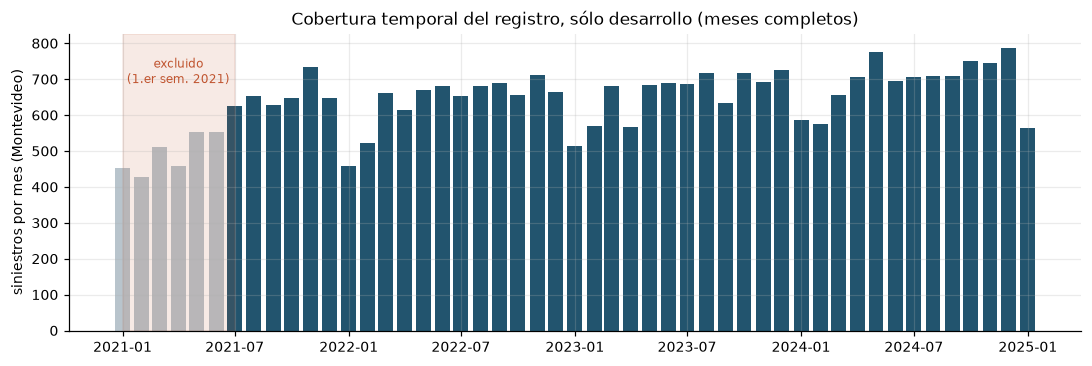

[tabla]  experiments\diagnostico_municipios\tablas\03b_objetivo_panel_desarrollo.csv


,indicador,valor
0,filas del panel de desarrollo,10528.0000
1,siniestros,28535.0000
2,% de ceros,9.3400
3,"media por (día, municipio)",2.7104
4,varianza (ddof=0),3.4415
5,índice de dispersión (var/media),1.2700
6,máximo,13.0000
7,modo,2.0000
8,% de filas con 1 siniestro,19.0500
9,% de filas con 2 o más,71.6100


[tabla]  experiments\diagnostico_municipios\tablas\05g_serie_departamental_desarrollo.csv


,indicador,valor
0,días con al menos un siniestro (de 1.316),1316
1,serie diaria del departamento: mínimo / median...,4 / 22.0 / 43
2,"Tukey global: Q1, Q3, IQR","17, 26, 9"
3,Tukey global: límites,3.5 y 39.5
4,Tukey global: días atípicos (arriba / abajo),7 (7 / 0)
5,Tukey por grupo de calendario: días atípicos (...,16 (14 / 2)
6,marcados por ambos criterios / sólo global / s...,7 / 0 / 9
7,atípicos por grupo que son feriado,0
8,días entre semana / fin de semana / feriado,891 / 364 / 61
9,media departamental: entre semana / fin de sem...,23.65 / 18.01 / 14.87


In [10]:
dep = y.sum(axis=1)

# --- Cobertura temporal anual (años con al menos 180 días de desarrollo; 2025 trae 36 y no se interpreta)
anual = dep.groupby(dep.index.year).agg(["sum", "count", "mean"])
anual = anual[anual["count"] >= 180]
variacion = [None, None] + [f"{100 * (anual['mean'].iloc[i] / anual['mean'].iloc[i - 1] - 1):+.1f} %" for i in range(2, len(anual))]
tab_anual = pd.DataFrame({"año": anual.index, "siniestros": anual["sum"].to_numpy(), "días observados": anual["count"].to_numpy(),
                          "media diaria": anual["mean"].round(2).to_numpy(),
                          "variación interanual": [("no comparable" if v is None else v) for v in variacion]})
guardar_tabla(tab_anual, "05f_cobertura_temporal_anual")

# --- Figura: siniestros mensuales (meses completos), con el tramo excluido señalado
mens = diario.groupby([diario.index.year, diario.index.month]).agg(["sum", "count"])
mens = mens[np.array([r["count"] == pd.Period(f"{a}-{m:02d}").days_in_month for (a, m), r in mens.iterrows()])]
fechas = [pd.Timestamp(a, m, 1) for a, m in mens.index]
fig, ax = plt.subplots(figsize=(10, 3.4))
colores = ["#b8c4cc" if f < pd.Timestamp(FECHA_INICIO) else "#22546e" for f in fechas]
ax.bar(fechas, mens["sum"].to_numpy(), width=24, color=colores)
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp(FECHA_INICIO), color="#c0542f", alpha=0.12)
ax.text(pd.Timestamp("2021-04-01"), mens["sum"].max() * 0.97, "excluido\n(1.er sem. 2021)", ha="center", va="top", fontsize=8, color="#c0542f")
ax.set_ylabel("siniestros por mes (Montevideo)"); ax.set_title("Cobertura temporal del registro, sólo desarrollo (meses completos)")
fig.tight_layout(); guardar_figura(fig, "fig8_cobertura_temporal")
plt.show()

# --- Variable objetivo y serie departamental del desarrollo
yv = pd.Series(y.to_numpy().ravel())
vc = yv.value_counts(normalize=True).sort_index() * 100
objetivo = pd.DataFrame([
    ("filas del panel de desarrollo", len(y) * len(ORDEN)),
    ("siniestros", int(y.to_numpy().sum())),
    ("% de ceros", round(100 * float((y.to_numpy() == 0).mean()), 2)),
    ("media por (día, municipio)", round(float(y.to_numpy().mean()), 4)),
    ("varianza (ddof=0)", round(float(y.to_numpy().var()), 4)),
    ("índice de dispersión (var/media)", round(float(y.to_numpy().var() / y.to_numpy().mean()), 3)),
    ("máximo", int(y.to_numpy().max())),
    ("modo", int(yv.mode()[0])),
    ("% de filas con 1 siniestro", round(float(vc.get(1, 0)), 2)),
    ("% de filas con 2 o más", round(float(vc[vc.index >= 2].sum()), 2)),
], columns=["indicador", "valor"])
guardar_tabla(objetivo, "03b_objetivo_panel_desarrollo")

q1, q3 = dep.quantile([0.25, 0.75]); iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
glob_ = (dep < lo) | (dep > hi)
fuera = pd.Series(False, index=dep.index)
for g in GRUPOS:
    v = dep[grupo == g]; a, b = v.quantile([0.25, 0.75])
    fuera.loc[v.index] = (v < a - 1.5 * (b - a)) | (v > b + 1.5 * (b - a))
mediana_grupo = dep.groupby(grupo).transform("median")
tipo_d = tipo_dia
serie_dep = pd.DataFrame([
    ("días con al menos un siniestro (de 1.316)", int((dep > 0).sum())),
    ("serie diaria del departamento: mínimo / mediana / máximo", f"{int(dep.min())} / {dep.median():.1f} / {int(dep.max())}"),
    ("Tukey global: Q1, Q3, IQR", f"{q1:g}, {q3:g}, {iqr:g}"),
    ("Tukey global: límites", f"{lo:g} y {hi:g}"),
    ("Tukey global: días atípicos (arriba / abajo)", f"{int(glob_.sum())} ({int((dep > hi).sum())} / {int((dep < lo).sum())})"),
    ("Tukey por grupo de calendario: días atípicos (arriba / abajo)", f"{int(fuera.sum())} ({int((fuera & (dep > mediana_grupo)).sum())} / {int((fuera & (dep < mediana_grupo)).sum())})"),
    ("marcados por ambos criterios / sólo global / sólo por grupo", f"{int((glob_ & fuera).sum())} / {int((glob_ & ~fuera).sum())} / {int((~glob_ & fuera).sum())}"),
    ("atípicos por grupo que son feriado", int((fuera & (tipo_d == 'feriado')).sum())),
    ("días entre semana / fin de semana / feriado", " / ".join(str(int((tipo_d == k).sum())) for k in ["entre_semana", "fin_semana", "feriado"])),
    ("media departamental: entre semana / fin de semana / feriado", " / ".join(f"{dep[tipo_d == k].mean():.2f}" for k in ["entre_semana", "fin_semana", "feriado"])),
    ("media departamental: viernes / domingo", f"{dep[dep.index.dayofweek == 4].mean():.2f} / {dep[dep.index.dayofweek == 6].mean():.2f}"),
    ("temperatura media: mínimo – máximo (°C)", f"{panel['temp_media'].min():g} – {panel['temp_media'].max():g}"),
    ("precipitación diaria: mínimo – máximo (mm)", f"{panel['precipitacion_mm'].min():g} – {panel['precipitacion_mm'].max():g}"),
], columns=["indicador", "valor"])
guardar_tabla(serie_dep, "05g_serie_departamental_desarrollo")

**Evidencia (tablas `05f`, `03b`, `05g`; figura `fig8`):**

- **Por año:** 2021 (jul–dic) 3.936 siniestros, 21,39 por día; 2022 7.665, 21,00; 2023 7.873, 21,57 (**+2,7 %**); 2024
  8.398, 22,95 (**+6,4 %**). 2021 y 2022 no son comparables (2021 es medio año).
- **Variable objetivo (desarrollo):** 10.528 filas, 28.535 siniestros, **9,34 %** de ceros, media **2,7104**,
  varianza 3,4415, dispersión **1,270**, máximo 13; el modo es 2; el 19,05 % de las filas vale uno y el 71,61 %, dos o
  más.
- **Serie departamental:** los 1.316 días tienen al menos un siniestro; mínimo 4, mediana 22,0, **máximo 43**.
  Tukey global: límites 3,5 y 39,5, **7** días atípicos (todos por arriba); por grupo de calendario, **16** (14 por arriba
  y 2 por debajo), ninguno feriado; 7 marcados por ambos criterios y 9 sólo por grupo.
- **Calendario del desarrollo:** 891 días entre semana, 364 de fin de semana y 61 feriados; medias departamentales
  de **23,65 / 18,01 / 14,87**; viernes **25,22** y domingo **15,72**.
- **Clima del desarrollo:** temperatura media de 4,9 a 31,7 °C; precipitación diaria de 0 a **58,9 mm**.

**Inferencia:** la lectura es la misma que con el período completo —conteo con sobredispersión leve, tendencia
creciente suave— pero **las cifras cambian** (por ejemplo, el máximo diario y la precipitación máxima del período
completo caen fuera del desarrollo). Estas son las que corresponde citar en el diagnóstico.

### 2.7 Distribución territorial de los siniestros

Mapa de los ocho municipios coloreado por los siniestros del **desarrollo** (tabla `05h`). Refleja **dónde se
registran** los siniestros, no dónde son más probables por unidad de exposición.

[figura] experiments\diagnostico_municipios\figuras\fig9_mapa_municipios.png


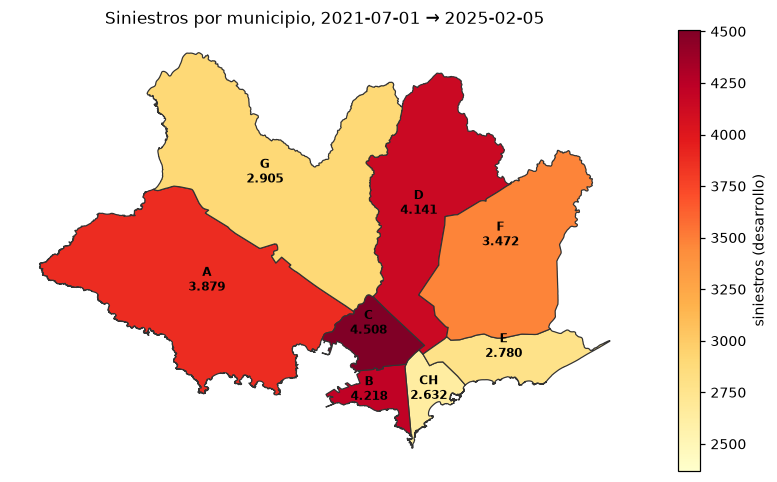

[tabla]  experiments\diagnostico_municipios\tablas\05h_siniestros_por_municipio_mapa.csv


,municipio,siniestros
0,C,4508
1,B,4218
2,D,4141
3,A,3879
4,F,3472
5,G,2905
6,E,2780
7,CH,2632


In [11]:
import geopandas as gpd

capa = gpd.read_file(RUTA_CAPA).to_crs("EPSG:4326")
col_nombre = next(c for c in ["municipio", "MUNICIPIO", "nombre", "NOMBRE"] if c in capa.columns)
capa["mun"] = capa[col_nombre].astype(str).str.strip()
assert set(capa["mun"]) == set(ORDEN), sorted(capa["mun"])
capa["siniestros"] = capa["mun"].map(y.sum())          # sólo desarrollo
fig, ax = plt.subplots(figsize=(7.4, 6))
capa.plot(column="siniestros", cmap="YlOrRd", edgecolor="#333333", linewidth=0.8, legend=True, ax=ax,
          legend_kwds={"label": "siniestros (desarrollo)", "shrink": 0.7}, vmin=y.sum().min() * 0.9)
for _, r in capa.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(f"{r['mun']}\n{int(r['siniestros']):,}".replace(",", "."), (p.x, p.y), ha="center", fontsize=8, weight="bold")
ax.set_axis_off(); ax.set_title(f"Siniestros por municipio, {FECHA_INICIO} → {ULTIMO_DIA_DES:%Y-%m-%d}")
fig.tight_layout(); guardar_figura(fig, "fig9_mapa_municipios")
plt.show()
guardar_tabla(capa[["mun", "siniestros"]].set_index("mun").loc[ORDEN].reset_index().rename(columns={"mun": "municipio"}), "05h_siniestros_por_municipio_mapa")

**Evidencia (figura `fig9`, tabla `05h`):** el reparto es parejo: de **4.508 (C)** a **2.632 (CH)** siniestros; razón
1,71. **Inferencia:** a favor, todos los municipios tienen soporte para estimar una tasa estable; en contra, queda
poco margen para ordenarlos. *Frase que estos datos NO sostienen:* «el municipio C es el más peligroso»: es el que
**más registra**, y no hay datos de exposición.

## 3. Tendencia por municipio

Media anual (el 2021 sólo aporta julio–diciembre; **el 2025 se omite porque el desarrollo sólo incluye
36 días de ese año**), cambio entre las dos mitades del desarrollo y pendiente log-lineal descontando el
calendario (GLM Poisson con escala de Pearson, es decir cuasi-Poisson). La pendiente se compara con la del
**agregado departamental** calculada igual, sobre el mismo desarrollo.

pendiente del agregado departamental: 3.72 %/año
[tabla]  experiments\diagnostico_municipios\tablas\06_media_anual_por_municipio.csv


,municipio,2021,2022,2023,2024,cambio 2022→2024 (%),cambio 1.ª→2.ª mitad (%)
0,C,3.4402,3.3726,3.3288,3.6421,8.0,7.3
1,B,3.1250,3.1507,3.2274,3.3388,6.0,4.6
2,D,3.0326,3.0932,3.1945,3.2322,4.5,5.5
3,A,2.8750,2.6685,2.9452,3.2869,23.2,15.0
4,F,2.4293,2.4822,2.7151,2.8497,14.8,15.4
5,G,2.0761,2.1041,2.2493,2.3607,12.2,12.8
6,E,2.1957,2.1288,2.0000,2.1885,2.8,-0.4
7,CH,2.2174,2.0000,1.9096,2.0464,2.3,2.0


[tabla]  experiments\diagnostico_municipios\tablas\07_pendiente_por_municipio.csv


,municipio,pendiente (%/año),IC95 inf,IC95 sup,p,IC contiene la pendiente del agregado
0,C,3.17,0.16,6.27,0.038600,True
1,B,2.33,-0.70,5.45,0.133000,True
2,D,2.77,-0.34,5.98,0.081300,True
3,A,7.34,4.02,10.77,0.000010,False
4,F,7.04,3.61,10.58,0.000042,True
5,G,5.50,1.78,9.36,0.003460,True
6,E,1.02,-2.83,5.03,0.608000,True
7,CH,-0.07,-3.89,3.90,0.972000,True


[figura] experiments\diagnostico_municipios\figuras\fig1_tendencia_por_municipio.png


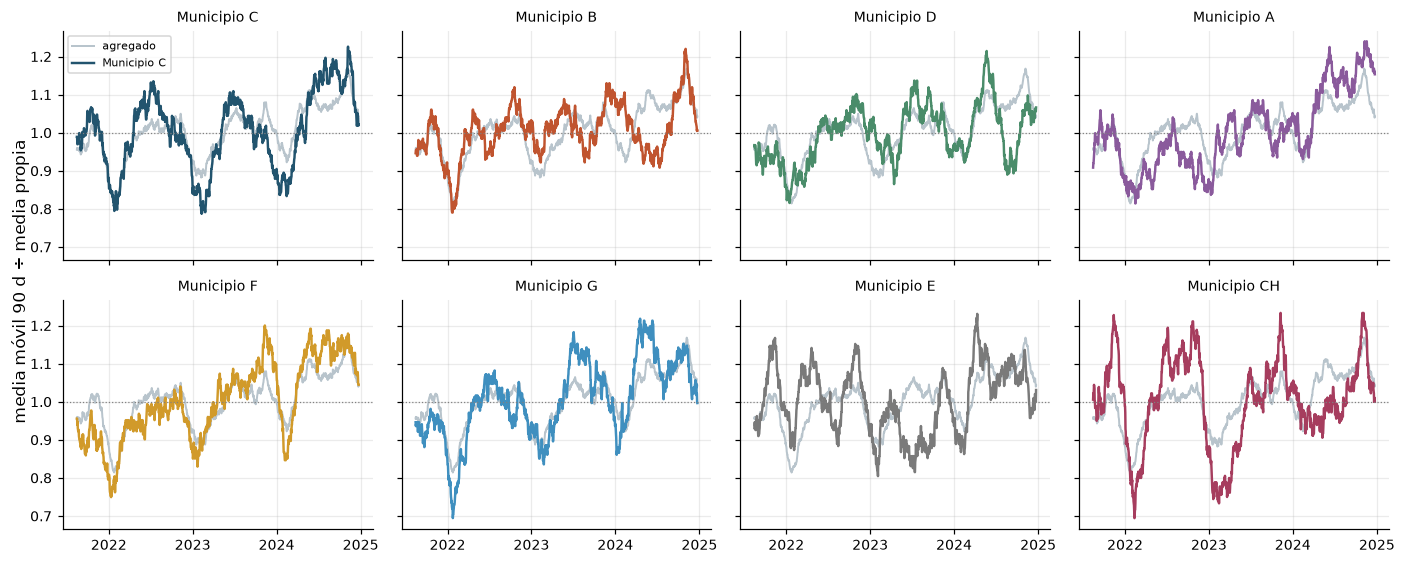

In [12]:
anio = y.index.year
dias_por_anio = pd.Series(anio).value_counts()
anios_ok = sorted(dias_por_anio[dias_por_anio >= 180].index)   # 2021 (jul–dic) y años completos; 2025 sólo tiene 36 días de desarrollo
sel = np.isin(anio, anios_ok)
media_anual = y[sel].groupby(y.index.year[sel]).mean().T.round(4)
media_anual.index.name = "municipio"
media_anual["cambio 2022→2024 (%)"] = (100 * (media_anual[2024] / media_anual[2022] - 1)).round(1)
mitad = N // 2
media_anual["cambio 1.ª→2.ª mitad (%)"] = [round(100 * (y[m].iloc[mitad:].mean() / y[m].iloc[:mitad].mean() - 1), 1) for m in media_anual.index]
media_anual.columns = [str(c) for c in media_anual.columns]

# Pendiente log-lineal por municipio, descontando calendario (Poisson cuasi-verosímil: la escala sale de Pearson)
t_anios = pd.Series((DIAS - DIAS[0]).days / 365.25, index=DIAS)
filas = []
for m in ORDEN:
    d = pd.DataFrame({"y": y[m], "grupo": grupo, "t": t_anios})
    ajuste = smf.glm("y ~ C(grupo) + t", d, family=sm.families.Poisson()).fit(scale="X2")
    lo, hi = ajuste.conf_int().loc["t"]
    filas.append({"municipio": m, "pendiente (%/año)": round(100 * (np.exp(ajuste.params["t"]) - 1), 2),
                  "IC95 inf": round(100 * (np.exp(lo) - 1), 2), "IC95 sup": round(100 * (np.exp(hi) - 1), 2),
                  "p": float(f"{ajuste.pvalues['t']:.3g}")})
pend = pd.DataFrame(filas)
dagg = pd.DataFrame({"y": y.sum(axis=1), "grupo": grupo, "t": t_anios})
ag = smf.glm("y ~ C(grupo) + t", dagg, family=sm.families.Poisson()).fit(scale="X2")
PEND_AGREGADA = 100 * (np.exp(ag.params["t"]) - 1)
pend["IC contiene la pendiente del agregado"] = (pend["IC95 inf"] <= PEND_AGREGADA) & (PEND_AGREGADA <= pend["IC95 sup"])
print(f"pendiente del agregado departamental: {PEND_AGREGADA:.2f} %/año")

guardar_tabla(media_anual.reset_index(), "06_media_anual_por_municipio")
guardar_tabla(pend, "07_pendiente_por_municipio")

fig, axes = plt.subplots(2, 4, figsize=(13, 5.2), sharex=True, sharey=True)
agregado = (y.sum(axis=1) / y.sum(axis=1).mean()).rolling(90, center=True).mean()
for ax, m in zip(axes.ravel(), ORDEN):
    norm = (y[m] / y[m].mean()).rolling(90, center=True).mean()
    ax.plot(agregado.index, agregado.values, color="#b8c4cc", lw=1.3, label="agregado")
    ax.plot(norm.index, norm.values, color=COLORES[m], lw=1.6, label=f"Municipio {m}")
    ax.set_title(f"Municipio {m}", fontsize=9); ax.axhline(1, color="grey", ls=":", lw=0.8)
    ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 0].legend(fontsize=7, loc="upper left")
fig.supylabel("media móvil 90 d ÷ media propia"); fig.tight_layout()
guardar_figura(fig, "fig1_tendencia_por_municipio")
plt.show()

**Evidencia (tablas `06` y `07`, figura `fig1`):**

- **La tendencia no es igual en los ocho.** La pendiente va de **−0,07 %/año (CH)** a **7,34 %/año (A)**,
  contra **3,72 %/año del agregado**. Es significativa al 5 % sólo en **C (3,17), A (7,34), F (7,04) y G
  (5,50)**; en B (2,33; p = 0,13), D (2,77; p = 0,08), **E (1,02; p = 0,61) y CH (−0,07; p = 0,97)** no se
  detecta.
- **Sólo A se aparta del agregado:** su IC95 (4,02 % a 10,77 %) no contiene 3,72 %. Los demás intervalos
  son anchos y lo contienen. A y F tienen el mayor cambio entre mitades (+15,0 % y +15,4 %); E (−0,4 %) y
  CH (+2,0 %) casi ninguno.
- **La forma tampoco es la misma:** B, D, F y G suben casi todos los años; **C, E y CH bajan hasta 2023 y
  recién después suben** (p. ej. E: 2,20 → 2,13 → 2,00 → 2,19).

**Inferencia del equipo:** **no puede afirmarse una tendencia común.** En cuatro municipios es creciente y
detectable, en dos (E, CH) no se distingue de cero, y A es la más empinada. Que la prueba formal de la
sección 7.1 sólo detecte una diferencia de tendencia marginal (p = 0,033; 0,13 % de la desvianza) es compatible
con que los intervalos individuales son anchos: **con ~3,6 años de datos una pendiente de 2–3 %/año no
siempre se separa de 0 (B, D)**. Que A crezca más rápido concuerda con que sea el municipio donde un
nivel fijado en el pasado más se queda corto (sección 7.4): es consistencia, no causalidad. *Nota:* el 2021
cubre medio año, así que su media anual no es comparable con las de 2022–2024.

**Robustez (7.6):** con **sólo el entrenamiento**, la pendiente del agregado es de 2,61 %/año y es detectable
únicamente en **B, F y G**; **A (3,89 %/año, p = 0,13) deja de apartarse del agregado**. «A tiene la pendiente mayor»
**depende de la ventana de validación**: es citable (el desarrollo es válido), pero conviene decirlo con esa salvedad.

## 4. Estacionalidad semanal y anual

### 4.1 Perfil semanal y feriado

Cada día de la semana (y el feriado como grupo aparte) dividido por la media del propio municipio: así
se comparan **formas** y no niveles.

[tabla]  experiments\diagnostico_municipios\tablas\08_perfil_calendario_normalizado.csv


,municipio,lunes,martes,miércoles,jueves,viernes,sábado,domingo,feriado
0,C,1.1451,1.0526,1.1628,1.0580,1.2427,0.8966,0.5662,0.6700
1,B,1.0493,1.1024,1.0754,1.0773,1.1951,0.8828,0.7577,0.5984
2,D,1.0991,1.0434,1.0457,1.0728,1.1583,0.8958,0.7997,0.6825
3,A,1.0137,1.0216,0.9931,0.9184,1.1717,1.1427,0.8183,0.7620
4,F,1.0897,0.9981,1.0185,1.0596,1.1723,0.9163,0.8143,0.8140
5,G,1.0786,1.0168,1.0933,1.0362,1.0942,0.9907,0.7741,0.7723
6,E,1.0341,1.1361,1.0711,1.1508,1.2235,0.8531,0.6502,0.6596
7,CH,1.1875,1.0944,1.1676,1.1077,1.1284,0.8654,0.6319,0.5082


[tabla]  experiments\diagnostico_municipios\tablas\09_resumen_perfil_semanal.csv


,municipio,viernes ÷ domingo,día máximo,día mínimo,correlación con el perfil del agregado,desvío máx. vs. perfil agregado,feriado: observado ÷ esperado por día de semana
0,C,2.19,viernes,domingo,0.992,0.160,0.637
1,B,1.58,viernes,domingo,0.972,0.048,0.581
2,D,1.45,viernes,domingo,0.975,0.073,0.659
3,A,1.43,viernes,domingo,0.609,0.212,0.757
4,F,1.44,viernes,domingo,0.953,0.088,0.793
5,G,1.41,viernes,domingo,0.962,0.079,0.750
6,E,1.88,viernes,domingo,0.959,0.091,0.643
7,CH,1.79,lunes,domingo,0.954,0.100,0.474


[figura] experiments\diagnostico_municipios\figuras\fig2_perfil_semanal.png


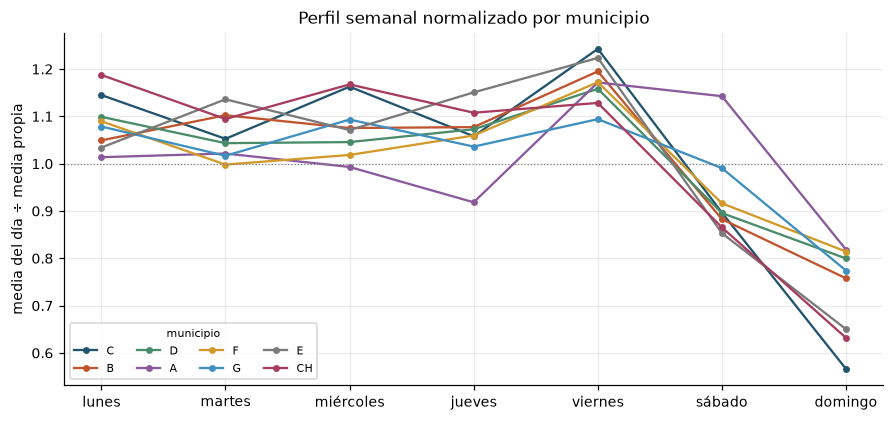

In [13]:
perfil = pd.DataFrame({m: y[m].groupby(grupo).mean().reindex(GRUPOS) / y[m].mean() for m in ORDEN}).T
perfil.index.name = "municipio"
perfil_semana = perfil[ORDEN_SEMANA]
resumen_sem = pd.DataFrame({
    "viernes ÷ domingo": (perfil["viernes"] / perfil["domingo"]).round(2),
    "día máximo": perfil_semana.idxmax(axis=1), "día mínimo": perfil_semana.idxmin(axis=1),
    "correlación con el perfil del agregado": [round(np.corrcoef(perfil_semana.loc[m], perfil_semana.mean())[0, 1], 3) for m in ORDEN],
    "desvío máx. vs. perfil agregado": [round((perfil_semana.loc[m] - perfil_semana.mean()).abs().max(), 3) for m in ORDEN],
})
# Feriado: observado ÷ esperado por el día de la semana en que cae
filas = []
for m in ORDEN:
    media_dow = y[m][~es_fer].groupby(DIAS[~es_fer].dayofweek).mean()
    esperado = media_dow.reindex(DIAS[es_fer].dayofweek).to_numpy().sum()
    filas.append(round(y[m][es_fer].sum() / esperado, 3))
resumen_sem["feriado: observado ÷ esperado por día de semana"] = filas

guardar_tabla(perfil.round(4).reset_index(), "08_perfil_calendario_normalizado")
guardar_tabla(resumen_sem.reset_index(), "09_resumen_perfil_semanal")

fig, ax = plt.subplots(figsize=(8.2, 3.9))
for m in ORDEN:
    ax.plot(ORDEN_SEMANA, perfil_semana.loc[m].values, marker="o", ms=3.5, lw=1.5, color=COLORES[m], label=m)
ax.axhline(1, color="grey", ls=":", lw=0.8)
ax.set_ylabel("media del día ÷ media propia"); ax.set_title("Perfil semanal normalizado por municipio")
ax.legend(ncol=4, fontsize=7.5, title="municipio", title_fontsize=7.5)
fig.tight_layout(); guardar_figura(fig, "fig2_perfil_semanal")
plt.show()

**Evidencia (tablas `08` y `09`, figura `fig2`):**

- **Domingo es el día más bajo en los ocho**, y los feriados quedan por debajo de lo esperado para su día de
  la semana en los ocho (observado ÷ esperado entre **0,47 (CH)** y **0,79 (F)**).
- **El día más alto es el viernes en siete municipios**; en **CH es el lunes** (1,188 contra 1,128 del
  viernes). La razón viernes/domingo va de **1,41 (G) a 2,19 (C)**.
- **A tiene un perfil distinto:** es el único donde el **sábado supera la media (1,14)**; en los otros siete
  va de 0,85 a 0,99. Además miércoles y jueves quedan por debajo de 1 (0,99 y 0,92). Su correlación con el
  perfil del agregado es **0,609**; en los otros siete es **≥ 0,953**.

**Inferencia del equipo:** el rasgo "fin de semana bajo, viernes alto, feriado bajo" es **común**, con
amplitud distinta (C el más marcado, G el más plano). **A es el único cuyo patrón semanal cambia de
forma.** Esto responde con una pista concreta la pregunta que dejó abierta el diagnóstico previo de A
(retirado de `main`): «¿por qué el patrón de A es más débil?»: no es sólo más débil, es **distinto en el sábado**. La
causa no se investigó.

**Robustez (7.6):** con sólo el entrenamiento el sábado de A es **1,111** (siguiente: G con 1,003) y su correlación
con el agregado **0,769**: la diferencia de A **se sostiene**, aunque algo atenuada. Decir «único con el sábado sobre
la media» sólo vale para el desarrollo; con el entrenamiento, G queda en ≈ 1.

### 4.2 Estacionalidad anual

Índice estacional mensual: cada mes dividido por la media de *su propio año*, promediado entre años.
**Sólo se usan los tres años completos del desarrollo (2022, 2023 y 2024)**, es decir **3 observaciones por
mes y municipio**: es un patrón **muy frágil**; se lo compara entre municipios, no se lo interpreta por
separado.

[tabla]  experiments\diagnostico_municipios\tablas\10_indice_estacional_mensual.csv


,mes,C,B,D,A,F,G,E,CH
0,1,0.7057,0.8819,0.8404,0.7984,0.7331,0.7749,0.6479,0.6913
1,2,0.8295,0.9726,0.9772,0.8725,0.8621,0.7486,1.0440,0.8569
2,3,0.9465,0.9806,0.9155,1.0514,0.9464,1.0553,1.1249,0.9100
3,4,0.9744,1.0199,0.9644,0.9429,1.0275,0.9134,0.9630,0.8095
4,5,1.0396,1.0092,1.0034,1.0282,0.9728,1.1306,1.1572,1.0952
5,6,1.1479,0.9835,1.1614,1.0112,1.0374,1.0566,0.9735,0.9676
6,7,1.0496,0.8698,1.0192,1.0716,1.1124,1.0962,0.7722,1.0685
7,8,1.1335,1.0267,0.9226,1.0730,0.9766,1.0673,1.0941,1.0143
8,9,1.0247,1.0367,1.0248,1.0146,1.0744,1.0455,1.0177,1.0401
9,10,1.0529,1.0538,1.0639,0.9842,1.0615,0.9821,0.9367,1.2212


[tabla]  experiments\diagnostico_municipios\tablas\11_resumen_estacionalidad_anual.csv


,municipio,mes mínimo,índice mínimo,mes máximo,índice máximo,amplitud (máx − mín),correlación con el patrón de los otros 7
0,C,1,0.706,6,1.148,0.442,0.855
1,B,7,0.870,11,1.155,0.285,0.589
2,D,1,0.840,6,1.161,0.321,0.627
3,A,1,0.798,11,1.093,0.294,0.880
4,F,1,0.733,7,1.112,0.379,0.822
5,G,2,0.749,5,1.131,0.382,0.791
6,E,1,0.648,11,1.164,0.516,0.560
7,CH,1,0.691,10,1.221,0.530,0.812


[figura] experiments\diagnostico_municipios\figuras\fig3_estacionalidad_anual.png


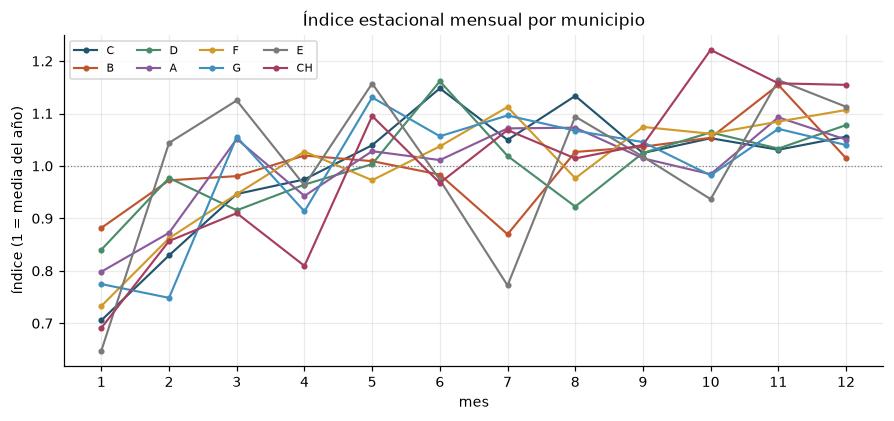

In [14]:
ANIOS_COMPLETOS = [2022, 2023, 2024]   # los únicos años completos dentro del desarrollo
yc = y[y.index.year.isin(ANIOS_COMPLETOS)]
assert len(yc) == 365 + 365 + 366
anio_ = yc.index.year; mes_ = yc.index.month
indice_mensual = pd.DataFrame({m: (yc[m] / yc[m].groupby(anio_).transform("mean")).groupby(mes_).mean() for m in ORDEN})
indice_mensual.index.name = "mes"
guardar_tabla(indice_mensual.round(4).reset_index(), "10_indice_estacional_mensual")

resumen_anual = pd.DataFrame({
    "mes mínimo": indice_mensual.idxmin(), "índice mínimo": indice_mensual.min().round(3),
    "mes máximo": indice_mensual.idxmax(), "índice máximo": indice_mensual.max().round(3),
    "amplitud (máx − mín)": (indice_mensual.max() - indice_mensual.min()).round(3),
    "correlación con el patrón de los otros 7": [round(np.corrcoef(indice_mensual[m], indice_mensual.drop(columns=m).mean(axis=1))[0, 1], 3) for m in ORDEN],
})
resumen_anual.index.name = "municipio"
guardar_tabla(resumen_anual.reset_index(), "11_resumen_estacionalidad_anual")

fig, ax = plt.subplots(figsize=(8.2, 3.9))
for m in ORDEN:
    ax.plot(indice_mensual.index, indice_mensual[m].values, marker="o", ms=3, lw=1.4, color=COLORES[m], label=m)
ax.axhline(1, color="grey", ls=":", lw=0.8)
ax.set_xticks(range(1, 13)); ax.set_xlabel("mes"); ax.set_ylabel("índice (1 = media del año)")
ax.set_title("Índice estacional mensual por municipio"); ax.legend(ncol=4, fontsize=7.5)
fig.tight_layout(); guardar_figura(fig, "fig3_estacionalidad_anual")
plt.show()

**Evidencia (tablas `10` y `11`, figura `fig3`):** **enero es el mes más bajo en seis de los ocho** (C, D,
A, F, E, CH; índice entre 0,65 y 0,84); en **B es julio (0,870)** y en **G febrero (0,749**, con enero en
0,775). El mes más alto **no coincide**: junio (C, D), julio (F), mayo (G), octubre (CH) o noviembre (B, A,
E). La amplitud va de 0,29 (B) a 0,53 (CH), y la correlación de cada patrón con el promedio de los otros
siete va de **0,56 (E) a 0,88 (A)**.

**Inferencia:** lo único que comparten con claridad es el enero bajo en seis de ocho. El resto de la forma
anual varía entre municipios, pero con tres observaciones por mes **no puede distinguirse diferencia real
de ruido** (la prueba formal está en la sección 7.1). *Frase que estos datos NO sostienen:* «el municipio X
tiene su pico de siniestros en <mes>»: con tres años por mes, el máximo de cada municipio cambia con poco.

### 4.3 Cuánta varianza diaria explica el calendario

Varianza de la serie diaria **del departamento** (en muestra, sólo desarrollo) explicada por tres codificaciones
del calendario: el **tipo de día** de tres niveles que exporta el ETL, el **día de la semana** (7 niveles) y el
**día de la semana más feriado** (8 niveles, el que usan los modelos mínimos de la sección 7). Es descriptivo:
no es una medición de predicción.

In [15]:
def r2(serie, clave):
    m = serie.groupby(clave).transform("mean")
    return 1 - float(((serie - m) ** 2).sum() / ((serie - serie.mean()) ** 2).sum())


varexp = pd.DataFrame([
    ("tipo de día (entre semana / fin de semana / feriado): 3 niveles", round(100 * r2(dep, tipo_dia), 2)),
    ("día de la semana: 7 niveles", round(100 * r2(dep, pd.Series(dep.index.dayofweek, index=dep.index)), 2)),
    ("día de la semana + feriado: 8 niveles", round(100 * r2(dep, grupo), 2)),
], columns=["calendario", "% de la varianza diaria del departamento explicada (en muestra, desarrollo)"])
guardar_tabla(varexp, "11b_varianza_explicada_por_calendario")

[tabla]  experiments\diagnostico_municipios\tablas\11b_varianza_explicada_por_calendario.csv


,calendario,"% de la varianza diaria del departamento explicada (en muestra, desarrollo)"
0,tipo de día (entre semana / fin de semana / fe...,21.42
1,día de la semana: 7 niveles,19.94
2,día de la semana + feriado: 8 niveles,26.51


**Evidencia (tabla `11b`):** el tipo de día de tres niveles explica **21,42 %** de la varianza diaria; el día de la
semana solo, **19,94 %**; el día de la semana más feriado (8 niveles), **26,51 %**.

**Inferencia del equipo:** resumir el calendario en tres niveles conserva **más** información que el día de la semana
solo, porque incorpora el feriado; pero **pierde ~5 puntos** frente al calendario de 8 niveles (distingue sábado de
domingo y cada día entre semana). La decisión del ETL de usar tres niveles se justificó contra el día de la semana,
no contra los 8 niveles. **No se cambia nada en esta sesión;** queda como decisión abierta para el Entregable 3.

## 5. Memoria temporal y transformación del objetivo

### 5.1 ACF del residuo de calendario y Ljung-Box

Se resta a cada día la media de su grupo de calendario y se calcula la ACF del residuo hasta el rezago 30,
con la banda analítica ±1,96/√n = **±0,0540** (n = 1.316). Ljung-Box sobre el mismo residuo en tres
horizontes.

[tabla]  experiments\diagnostico_municipios\tablas\12_acf_y_ljung_box_por_municipio.csv


,municipio,ACF cruda r1,cruda r7,cruda r14,ACF residuo r1,residuo r7,residuo r14,rezagos 1–30 fuera de banda (residuo),Ljung-Box p (7),Ljung-Box p (14),Ljung-Box p (28)
0,C,0.0557,0.0765,0.1636,0.0554,-0.0322,0.0560,4,0.00447,0.00663,0.0412
1,B,0.0117,0.0384,0.0158,-0.0127,-0.0113,-0.0218,3,0.01890,0.07760,0.4030
2,D,0.0459,0.0064,0.0277,0.0453,-0.0249,-0.0019,2,0.33500,0.02580,0.0152
3,A,0.0362,0.0309,0.0441,0.0421,0.0087,0.0158,2,0.20100,0.28500,0.5250
4,F,0.0526,0.0698,0.0415,0.0517,0.0446,0.0167,3,0.15100,0.49600,0.0623
5,G,-0.0214,0.0322,0.0164,-0.0175,0.0149,0.0013,2,0.05160,0.35800,0.5260
6,E,0.0531,0.0933,0.0687,0.0367,0.0413,0.0169,3,0.12900,0.06060,0.1130
7,CH,0.0661,0.0798,0.0532,0.0468,0.0239,0.0028,4,0.00150,0.00520,0.0169


banda analítica 95 %: ±0.0540  (esperables por azar: 1.5 de 30 rezagos)


[figura] experiments\diagnostico_municipios\figuras\fig4_acf_residuo_por_municipio.png


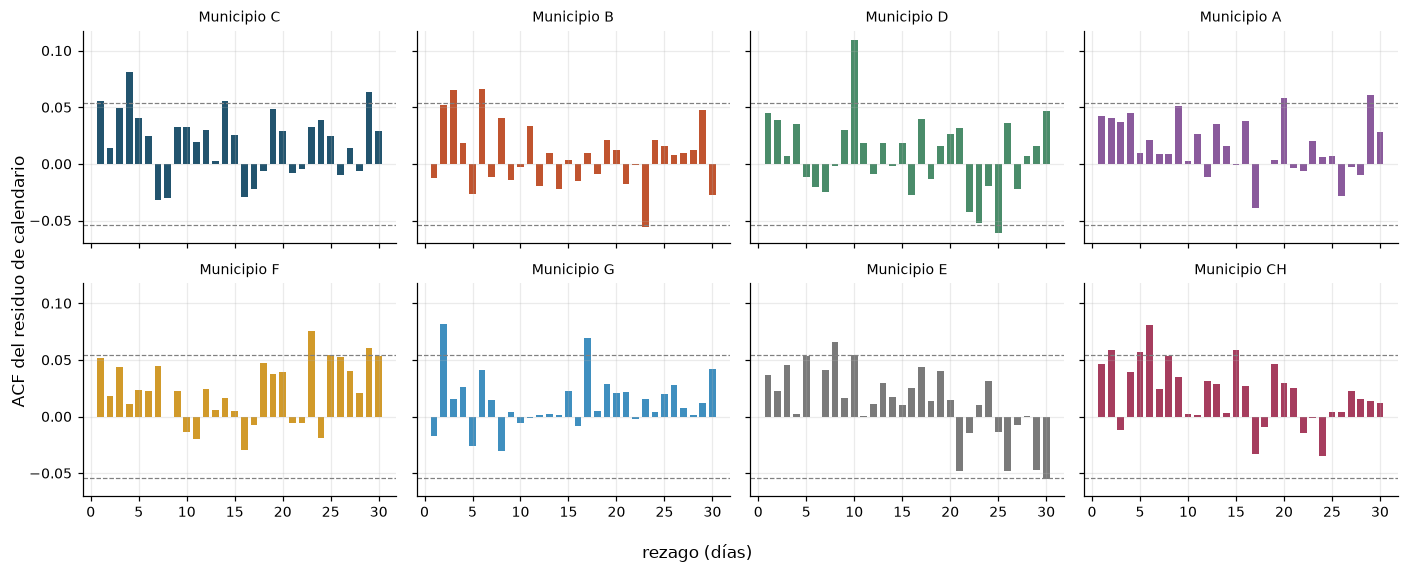

In [16]:
NLAGS = 30
banda_95 = 1.96 / np.sqrt(N)
residuos = {}
acfs_res = {}
filas = []
for m in ORDEN:
    vals = y[m].to_numpy(float)
    res = vals - y[m].groupby(grupo).transform("mean").to_numpy()
    residuos[m] = res
    a_cruda = acf(vals, nlags=NLAGS, fft=True)
    a_res = acf(res, nlags=NLAGS, fft=True)
    acfs_res[m] = a_res
    lb = acorr_ljungbox(res, lags=[7, 14, 28])["lb_pvalue"]
    filas.append({
        "municipio": m,
        "ACF cruda r1": round(a_cruda[1], 4), "cruda r7": round(a_cruda[7], 4), "cruda r14": round(a_cruda[14], 4),
        "ACF residuo r1": round(a_res[1], 4), "residuo r7": round(a_res[7], 4), "residuo r14": round(a_res[14], 4),
        "rezagos 1–30 fuera de banda (residuo)": int((np.abs(a_res[1:]) > banda_95).sum()),
        "Ljung-Box p (7)": float(f"{lb.iloc[0]:.3g}"), "Ljung-Box p (14)": float(f"{lb.iloc[1]:.3g}"),
        "Ljung-Box p (28)": float(f"{lb.iloc[2]:.3g}"),
    })
acf_tab = pd.DataFrame(filas)
guardar_tabla(acf_tab, "12_acf_y_ljung_box_por_municipio")
print(f"banda analítica 95 %: ±{banda_95:.4f}  (esperables por azar: {0.05 * NLAGS:.1f} de {NLAGS} rezagos)")

fig, axes = plt.subplots(2, 4, figsize=(13, 5.2), sharex=True, sharey=True)
for ax, m in zip(axes.ravel(), ORDEN):
    ax.bar(range(1, NLAGS + 1), acfs_res[m][1:], color=COLORES[m], width=0.7)
    ax.axhline(banda_95, color="grey", ls="--", lw=0.8); ax.axhline(-banda_95, color="grey", ls="--", lw=0.8)
    ax.set_title(f"Municipio {m}", fontsize=9)
fig.supxlabel("rezago (días)"); fig.supylabel("ACF del residuo de calendario"); fig.tight_layout()
guardar_figura(fig, "fig4_acf_residuo_por_municipio")
plt.show()

**Evidencia (tabla `12`, figura `fig4`):**

- **La memoria es pequeña en los ocho:** el rezago 1 del residuo va de **−0,018 (G) a 0,055 (C)**, es decir
  menos del 0,3 % de la varianza. **Sólo C (0,0554) queda por encima de la banda**, y por poco; F (0,0517) y
  CH (0,0468) quedan cerca, el resto lejos.
- **Los múltiplos de 7 eran calendario:** en la ACF cruda el rezago 7 supera la banda en C, F, E y CH, pero
  **en el residuo ninguno de los ocho** lo supera. Sólo **C** conserva algo en el rezago 14 (0,0560).
- **Ljung-Box (residuo):** **C y CH rechazan** la ausencia de autocorrelación (p < 0,05) **en los tres
  horizontes** (C: 0,004; 0,007; 0,041. CH: 0,0015; 0,005; 0,017). D rechaza en 14 y 28 (0,026; 0,015), B
  sólo en 7 (0,019). **A, F, G y E no rechazan en ningún horizonte.**
- Rezagos 1–30 fuera de banda: de **2 a 4** por municipio, contra 1,5 esperables por azar.

**Inferencia del equipo:** en el desarrollo la señal temporal posterior al calendario es **débil y sólo
detectable en C y CH** (y de forma menos consistente en D y B); en los otros cuatro no se distingue del
ruido. **No hay un municipio con una memoria cualitativamente distinta**, pero tampoco una memoria común a
los ocho: el rezago de 1 día es candidato, no un supuesto, y su aporte probable es pequeño.

**Robustez (7.6):** con sólo el entrenamiento, Ljung-Box sobre el residuo rechaza **únicamente en CH**; **C no rechaza**
(p = 0,069; 0,147; 0,364). La memoria de C es, entonces, un hallazgo del desarrollo que depende de la ventana de
validación.

### 5.2 Estacionariedad, diferenciación y Box-Cox

Diagnóstico de estacionariedad, ahora en los ocho: ADF y KPSS, efecto de
diferenciar una vez, λ de Box-Cox por máxima verosimilitud (sobre serie+1) y relación entre la media y
la varianza mensuales.

In [17]:
filas = []
for m in ORDEN:
    vals = y[m].to_numpy(float)
    men = y[m].groupby([y.index.year, y.index.month]).agg(["mean", "var", "size"])
    men = men[men["size"] >= 28]   # sólo meses completos: febrero de 2025 tiene 5 días en el desarrollo
    pend_mv, ord_mv = np.polyfit(men["mean"], men["var"], 1)
    filas.append({
        "municipio": m,
        "ADF p": float(f"{adfuller(vals, autolag='AIC')[1]:.3g}"),
        "KPSS p (acotado a [0,01; 0,10])": round(kpss(vals, regression="c", nlags="auto")[1], 3),
        "ACF r1 tras diferenciar (d=1)": round(acf(np.diff(vals), nlags=1)[1], 3),
        "λ Box-Cox (MLE, serie+1)": round(sps.boxcox(vals + 1)[1], 3),
        "pendiente var~media mensual": round(pend_mv, 3),
        "correlación media–varianza mensual": round(np.corrcoef(men["mean"], men["var"])[0, 1], 3),
    })
transf = pd.DataFrame(filas)
guardar_tabla(transf, "13_estacionariedad_y_transformacion")

[tabla]  experiments\diagnostico_municipios\tablas\13_estacionariedad_y_transformacion.csv


,municipio,ADF p,"KPSS p (acotado a [0,01; 0,10])",ACF r1 tras diferenciar (d=1),"λ Box-Cox (MLE, serie+1)",pendiente var~media mensual,correlación media–varianza mensual
0,C,7.620000e-09,0.084,-0.464,0.448,1.563,0.513
1,B,3.510000e-20,0.100,-0.513,0.497,0.874,0.354
2,D,0.000000e+00,0.100,-0.486,0.409,1.377,0.488
3,A,0.000000e+00,0.010,-0.493,0.461,0.967,0.433
4,F,0.000000e+00,0.010,-0.477,0.420,1.093,0.576
5,G,0.000000e+00,0.010,-0.549,0.419,1.389,0.593
6,E,1.010000e-18,0.100,-0.470,0.251,0.771,0.369
7,CH,1.330000e-17,0.100,-0.484,0.257,1.399,0.640


**Evidencia (tabla `13`):**

- **ADF rechaza raíz unitaria en los ocho** (p ≤ 8·10⁻⁹). **KPSS rechaza estacionariedad en tres** (A, F y
  G, p en el borde de 0,01) y **no la rechaza en cinco** (C 0,084; B, D, E y CH en el tope de 0,10).
- **Diferenciar una vez sobrediferencia en los ocho:** la ACF en el rezago 1 queda entre **−0,46 y −0,55**
  (un ruido puro diferenciado da −0,5).
- **λ de Box-Cox:** C, B, D, A, F y G entre **0,41 y 0,50** (cerca de la raíz cuadrada); **E (0,25) y CH
  (0,26)**, entre el logaritmo y la raíz cuadrada.
- **Pendiente media-varianza mensual:** de 0,77 (E) a 1,56 (C), con 43 puntos mensuales por municipio:
  demasiado ruidosa para interpretarla por separado.

**Inferencia del equipo:** en el desarrollo la serie se comporta como estacionaria en la mayoría (ADF
rechaza en todos y KPSS sólo discrepa en A, F y G). **La decisión que ya se había tomado para C y A —no
diferenciar ni aplicar logaritmo— se extiende a los ocho.** Si algún método exigiera estabilizar varianza,
la raíz cuadrada sirve para seis municipios pero **no es la transformación óptima para los de menor media
(E, CH)**: argumento adicional a favor de pérdidas de la familia Poisson, que no requieren transformar.

### 5.3 Rezagos candidatos: ACF sólo con el entrenamiento inicial

Los rezagos 7, 14 y 21 del árbol candidato se eligieron con una ACF calculada sobre **todo el período**. Como
verificación complementaria (la validación puede usarse en los diagnósticos; el test, no), se recalcula la ACF **sólo con el entrenamiento inicial**
(987 días, 2021-07-01 → 2024-03-13; banda ±1,96/√987 = ±0,0624), con la media de cada grupo de calendario estimada
también sólo ahí, en los rezagos 1, 7, 14, 21 y 28.

In [18]:
# Los rezagos candidatos se eligen mirando SÓLO el entrenamiento inicial (987 días): ni la validación
# ni el test participan en esa elección. Media del grupo de calendario estimada también sólo ahí.
N_ENT = N_AJ
banda_ent = 1.96 / np.sqrt(N_ENT)
LAGS_VER = (1, 7, 14, 21, 28)
filas = []
for m in ORDEN:
    v = y[m].iloc[:N_ENT].to_numpy(float)
    res = v - y[m].iloc[:N_ENT].groupby(grupo.iloc[:N_ENT]).transform("mean").to_numpy()
    a_c, a_r = acf(v, nlags=max(LAGS_VER), fft=True), acf(res, nlags=max(LAGS_VER), fft=True)
    f = {"municipio": m}
    f.update({f"cruda r{k}": round(a_c[k], 4) for k in LAGS_VER})
    f.update({f"residuo r{k}": round(a_r[k], 4) for k in LAGS_VER})
    f["rezagos 1–28 fuera de banda (residuo)"] = int((np.abs(a_r[1:]) > banda_ent).sum())
    filas.append(f)
rez = pd.DataFrame(filas)
guardar_tabla(rez, "12b_acf_rezagos_solo_entrenamiento")
print(f"entrenamiento inicial: {DIAS[0]:%Y-%m-%d} → {DIAS[N_ENT - 1]:%Y-%m-%d} ({N_ENT} días) · banda ±{banda_ent:.4f}")

[tabla]  experiments\diagnostico_municipios\tablas\12b_acf_rezagos_solo_entrenamiento.csv


,municipio,cruda r1,cruda r7,cruda r14,cruda r21,cruda r28,residuo r1,residuo r7,residuo r14,residuo r21,residuo r28,rezagos 1–28 fuera de banda (residuo)
0,C,0.0465,0.0701,0.1609,0.0889,0.1359,0.0483,-0.0496,0.0457,-0.0238,0.0113,1
1,B,-0.0221,0.0351,-0.0168,0.0392,0.0258,-0.0414,-0.0100,-0.0598,-0.0173,-0.0157,1
2,D,0.0306,-0.0119,0.0392,0.0473,0.0398,0.0284,-0.0430,0.0089,0.0135,0.0020,2
3,A,0.0180,0.0396,0.0311,0.0108,0.0148,0.0311,0.0061,-0.0027,-0.0213,-0.0250,0
4,F,0.0664,0.0592,0.0013,0.0273,0.0444,0.0691,0.0332,-0.0271,0.0071,0.0214,2
5,G,-0.0376,0.0606,0.0232,0.0185,0.0214,-0.0294,0.0458,0.0072,0.0041,0.0025,0
6,E,0.0455,0.1078,0.0688,0.0323,0.0617,0.0294,0.0459,0.0104,-0.0367,-0.0033,2
7,CH,0.0718,0.1222,0.0533,0.0903,0.0886,0.0459,0.0611,-0.0032,0.0346,0.0342,3


entrenamiento inicial: 2021-07-01 → 2024-03-13 (987 días) · banda ±0.0624


**Evidencia (tabla `12b`):** en la serie **cruda**, los rezagos 7, 14, 21 y 28 superan la banda en **C** (0,070; 0,161;
0,089; 0,136), en **CH** (0,122 en el 7; 0,090 en el 21; 0,089 en el 28) y en **E** (0,108 en el 7; 0,069 en el 14).
**Sobre el residuo de calendario, ningún municipio supera la banda en los rezagos 1, 7, 14, 21 ni 28**
(el mayor valor absoluto es 0,0611, de CH en el rezago 7; C en el rezago 1: 0,0483). Rezagos 1–28 fuera de banda:
de 0 a 3 por municipio.

**Inferencia del equipo:** con el entrenamiento solo, **los rezagos que se ven en la serie cruda son calendario**:
descontado el calendario no queda memoria detectable en ningún municipio. Los rezagos 7, 14 y 21 del árbol
candidato **no tienen sustento adicional al calendario** en el entrenamiento. La memoria de **C** que la
sección 5.1 detecta aparece **al incluir el tramo de validación** (7.6: con sólo el entrenamiento Ljung-Box no rechaza
para C). La de **CH** también se detecta con el entrenamiento, por Ljung-Box conjunto, aunque ningún rezago individual
supera la banda. Puede ser ruido o un cambio de régimen reciente, y este notebook no lo distingue. *Advertencia de poder:* con 987 días una autocorrelación de 0,05 está en el límite de lo detectable.

## 6. ¿Se mueven juntos los municipios?

Correlación diaria entre los ocho, sobre la serie cruda y sobre el residuo de calendario. Si los
municipios compartieran choques diarios (un temporal, un evento masivo), el residuo estaría
correlacionado entre pares.

[tabla]  experiments\diagnostico_municipios\tablas\14_comovimiento_resumen.csv


,indicador,valor
0,"correlación media entre pares, serie cruda",0.0799
1,"correlación media entre pares, residuo de cale...",0.0327
2,"mínima / máxima entre pares, residuo",-0.035 / 0.094
3,"pares fuera de ±1,96/√n (residuo), de 28",4
4,"banda ±1,96/√n",0.054


[tabla]  experiments\diagnostico_municipios\tablas\15_correlacion_residuos.csv


,municipio,C,B,D,A,F,G,E,CH
0,C,1.000,0.025,0.040,0.060,0.076,0.094,0.038,0.025
1,B,0.025,1.000,0.007,0.021,0.052,-0.035,0.016,0.014
2,D,0.040,0.007,1.000,0.055,-0.002,0.054,0.035,0.043
3,A,0.060,0.021,0.055,1.000,0.029,0.010,0.043,0.016
4,F,0.076,0.052,-0.002,0.029,1.000,0.014,0.004,0.049
5,G,0.094,-0.035,0.054,0.010,0.014,1.000,0.048,0.046
6,E,0.038,0.016,0.035,0.043,0.004,0.048,1.000,0.034
7,CH,0.025,0.014,0.043,0.016,0.049,0.046,0.034,1.000


[figura] experiments\diagnostico_municipios\figuras\fig5_correlacion_entre_municipios.png


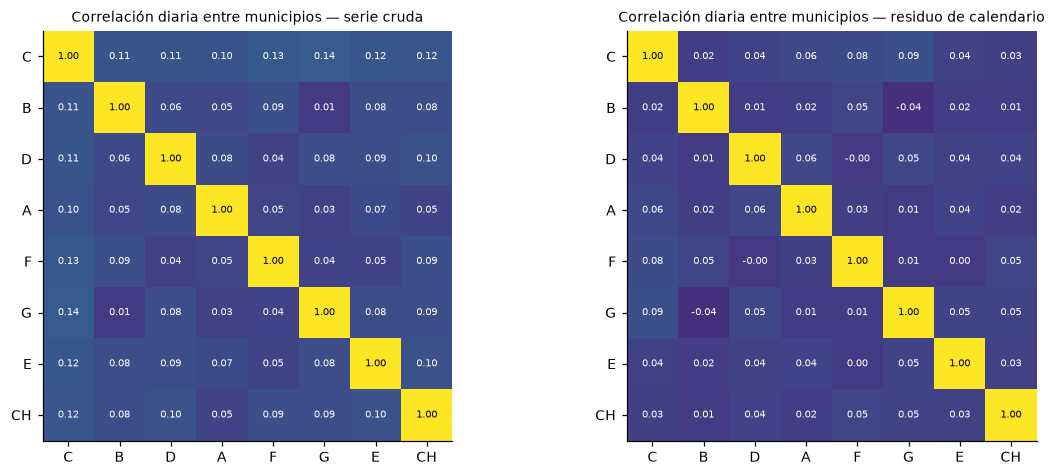

In [19]:
res_df = pd.DataFrame(residuos, index=DIAS)[ORDEN]
corr_cruda = y.corr()
corr_res = res_df.corr()
iu = np.triu_indices(len(ORDEN), k=1)
resumen_corr = pd.DataFrame([
    ("correlación media entre pares, serie cruda", round(corr_cruda.values[iu].mean(), 4)),
    ("correlación media entre pares, residuo de calendario", round(corr_res.values[iu].mean(), 4)),
    ("mínima / máxima entre pares, residuo", f"{corr_res.values[iu].min():.3f} / {corr_res.values[iu].max():.3f}"),
    ("pares fuera de ±1,96/√n (residuo), de 28", int((np.abs(corr_res.values[iu]) > banda_95).sum())),
    ("banda ±1,96/√n", round(banda_95, 4)),
], columns=["indicador", "valor"])
guardar_tabla(resumen_corr, "14_comovimiento_resumen")
guardar_tabla(corr_res.round(3).rename_axis("municipio").reset_index(), "15_correlacion_residuos")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, M, tit in zip(axes, (corr_cruda, corr_res), ("serie cruda", "residuo de calendario")):
    ax.imshow(M.values, vmin=-0.2, vmax=1, cmap="viridis")
    ax.set_xticks(range(8)); ax.set_xticklabels(ORDEN); ax.set_yticks(range(8)); ax.set_yticklabels(ORDEN)
    for i in range(8):
        for j in range(8):
            ax.text(j, i, f"{M.values[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if M.values[i, j] < 0.5 else "black")
    ax.set_title(f"Correlación diaria entre municipios — {tit}", fontsize=9); ax.grid(False)
fig.tight_layout(); guardar_figura(fig, "fig5_correlacion_entre_municipios")
plt.show()

**Evidencia (tablas `14` y `15`, figura `fig5`):** la correlación media entre pares es **0,080 en la serie
cruda** y **0,033 en el residuo**; el residuo va de −0,035 a 0,094 (el máximo, C–G). **4 de los 28 pares**
superan la banda de ±0,054 (se esperan 1,4 por azar).

**Inferencia:** casi toda la correlación cruda es **calendario compartido** (0,080 → 0,033). Lo que queda
es un componente común real pero mínimo (el mayor par explica menos del 1 % de la varianza): a escala
diaria, **dado el calendario, los municipios son prácticamente independientes**. Consecuencias: (i)
entrenar con los ocho aporta observaciones, no información redundante; (ii) no hay base en estos datos para
incluir como predictor lo que ocurre ese mismo día en otro municipio.

## 7. ¿Un solo modelo o varios?

Las secciones 2 a 6 muestran **parecidos y diferencias**. Esta sección mide cuánto importan para predecir.
Como todo el notebook, usa **sólo el bloque de desarrollo** (1.316 días, hasta 2025-02-05); además separa
ajuste y validación cronológicos dentro de él.

### 7.1 Pruebas de homogeneidad

Sobre el panel largo (1.316 días × 8 municipios = 10.528 observaciones) se compara, con una **prueba F de
cuasi-verosimilitud** (GLM Poisson, escala de Pearson), un modelo que **no** distingue municipios en un
aspecto contra otro que sí lo hace. Cada fila es una pregunta distinta; la última columna es el tamaño del
efecto (cuánto baja la desvianza en muestra), que es lo que importa para predecir.

In [20]:
# Sólo bloque de desarrollo: estas pruebas orientan una decisión de modelado.
des = slice(0, N_DES)
largo = pd.DataFrame({
    "y": y.iloc[des].to_numpy().ravel(),
    "mun": np.tile(np.array(ORDEN), N_DES),
    "grupo": np.repeat(grupo.iloc[des].to_numpy(), len(ORDEN)),
    "mes": np.repeat(DIAS[des].month.to_numpy(), len(ORDEN)),
    "t": np.repeat(t_anios.iloc[des].to_numpy(), len(ORDEN)),
    "llovio": np.repeat(llovio.iloc[des].to_numpy(), len(ORDEN)),
})
assert len(largo) == N_DES * len(ORDEN)
assert largo["y"].sum() == y.iloc[des].to_numpy().sum()


def prueba_cuasi_f(nula, alt, datos):
    """Prueba F de cuasi-verosimilitud entre dos GLM Poisson anidados (escala por Pearson del modelo grande)."""
    m0 = smf.glm(nula, datos, family=sm.families.Poisson()).fit()
    m1 = smf.glm(alt, datos, family=sm.families.Poisson()).fit()
    ddf = m0.df_resid - m1.df_resid
    phi = m1.pearson_chi2 / m1.df_resid
    F = (m0.deviance - m1.deviance) / ddf / phi
    return {"gl": int(ddf), "φ (dispersión)": round(phi, 3), "F": round(F, 2),
            "p": float(f"{sps.f.sf(F, ddf, m1.df_resid):.3g}"),
            "reducción de desvianza (%)": round(100 * (m0.deviance - m1.deviance) / m0.deviance, 3)}


PRUEBAS = [
    ("nivel propio por municipio", "y ~ C(grupo)", "y ~ C(grupo) + C(mun)"),
    ("perfil de calendario distinto por municipio", "y ~ C(grupo) + C(mun)", "y ~ C(grupo) * C(mun)"),
    ("tendencia distinta por municipio", "y ~ C(grupo) + C(mun) + t", "y ~ C(grupo) + C(mun) + t * C(mun)"),
    ("estacionalidad anual distinta por municipio", "y ~ C(grupo) + C(mun) + C(mes)", "y ~ C(grupo) + C(mun) + C(mes) * C(mun)"),
    ("efecto de la lluvia distinto por municipio", "y ~ C(grupo) + C(mun) + llovio", "y ~ C(grupo) + C(mun) + llovio * C(mun)"),
]
filas = [{"hipótesis alternativa": nombre, **prueba_cuasi_f(nula, alt, largo)} for nombre, nula, alt in PRUEBAS]
homog = pd.DataFrame(filas)
guardar_tabla(homog, "16_pruebas_de_homogeneidad")

[tabla]  experiments\diagnostico_municipios\tablas\16_pruebas_de_homogeneidad.csv


,hipótesis alternativa,gl,φ (dispersión),F,p,reducción de desvianza (%)
0,nivel propio por municipio,7,1.112,134.47,2.060000e-190,7.545
1,perfil de calendario distinto por municipio,49,1.102,2.71,1.460000e-09,1.139
2,tendencia distinta por municipio,7,1.108,2.18,3.250000e-02,0.132
3,estacionalidad anual distinta por municipio,77,1.094,1.38,1.560000e-02,0.919
4,efecto de la lluvia distinto por municipio,7,1.112,1.11,3.540000e-01,0.067


**Evidencia (tabla `16`):**

| Aspecto | F | p | Reducción de desvianza |
| --- | --- | --- | --- |
| Nivel propio por municipio | 134,47 | ≈ 2·10⁻¹⁹⁰ | **7,545 %** |
| Perfil de calendario distinto | 2,71 | 1,5·10⁻⁹ | 1,139 % |
| Tendencia distinta | 2,18 | 0,033 | 0,132 % |
| Estacionalidad anual distinta | 1,38 | 0,016 | 0,919 % (77 gl) |
| Efecto de la lluvia distinto | 1,11 | 0,35 | 0,067 % |

Con 5 pruebas, un corte de Bonferroni es 0,01: **sólo el nivel y el perfil de calendario lo
superan**. Los p-valores asumen errores independientes; la autocorrelación residual (hasta 0,055) y la
correlación entre municipios (0,033) los hacen algo optimistas, así que **0,016 y 0,033 deben leerse
como no concluyentes**.

**Inferencia del equipo:** el **nivel** es la heterogeneidad dominante (7,5 % de la desvianza, un orden de
magnitud sobre cualquier otra). El **perfil de calendario** es estadísticamente distinto pero su efecto
es chico (1,1 %). Tendencia, estacionalidad anual y lluvia no muestran diferencias que se puedan
sostener.

### 7.1b ¿Qué municipios se apartan del perfil de calendario del agregado?

Una prueba por municipio: su perfil propio contra el del agregado (sólo con el bloque de desarrollo),
con corrección de **Holm** por las 8 pruebas.

In [21]:
# ¿Cuáles municipios se apartan del perfil de calendario del agregado? Una prueba por municipio, con Holm sobre las 8.
sub = y.iloc[des]; g_des = grupo.iloc[des]
suma = sub.sum(axis=1)
f_agregado = (suma.groupby(g_des).mean() / suma.mean()).reindex(GRUPOS)
filas = []
for m in ORDEN:
    d = pd.DataFrame({"y": sub[m].to_numpy(), "grupo": g_des.to_numpy(), "log_f": np.log(g_des.map(f_agregado).to_numpy())})
    m0 = smf.glm("y ~ 1", d, family=sm.families.Poisson(), offset=d["log_f"]).fit()
    m1 = smf.glm("y ~ C(grupo)", d, family=sm.families.Poisson()).fit()
    ddf = m0.df_resid - m1.df_resid
    phi = m1.pearson_chi2 / m1.df_resid
    F = (m0.deviance - m1.deviance) / ddf / phi
    filas.append({"municipio": m, "gl": int(ddf), "F": round(F, 2), "p": sps.f.sf(F, ddf, m1.df_resid),
                  "reducción de desvianza (%)": round(100 * (m0.deviance - m1.deviance) / m0.deviance, 3)})
vs_agregado = pd.DataFrame(filas)
orden_p = vs_agregado["p"].argsort().to_numpy()
holm = np.empty(len(vs_agregado))
corriente = 0.0
for rango, i in enumerate(orden_p):
    corriente = max(corriente, (len(vs_agregado) - rango) * vs_agregado["p"].iloc[i])
    holm[i] = min(1.0, corriente)
vs_agregado["p Holm (8 pruebas)"] = holm
vs_agregado["se aparta del perfil agregado (Holm<0,05)"] = vs_agregado["p Holm (8 pruebas)"] < 0.05
vs_agregado["p"] = vs_agregado["p"].map(lambda v: float(f"{v:.3g}"))
vs_agregado["p Holm (8 pruebas)"] = vs_agregado["p Holm (8 pruebas)"].map(lambda v: float(f"{v:.3g}"))
guardar_tabla(vs_agregado, "17_perfil_calendario_vs_agregado")

[tabla]  experiments\diagnostico_municipios\tablas\17_perfil_calendario_vs_agregado.csv


,municipio,gl,F,p,reducción de desvianza (%),p Holm (8 pruebas),"se aparta del perfil agregado (Holm<0,05)"
0,C,7,4.28,1.100000e-04,2.074,0.000769,True
1,B,7,0.90,5.040000e-01,0.434,1.000000,False
2,D,7,0.74,6.350000e-01,0.376,1.000000,False
3,A,7,6.21,3.540000e-07,2.920,0.000003,True
4,F,7,1.58,1.390000e-01,0.768,0.680000,False
5,G,7,0.98,4.440000e-01,0.455,1.000000,False
6,E,7,1.58,1.360000e-01,0.761,0.680000,False
7,CH,7,2.63,1.070000e-02,1.251,0.064400,False


**Evidencia (tabla `17`):** se apartan **A** (F = 6,21; p de Holm = 3·10⁻⁶; 2,92 % de la desvianza propia) y
**C** (F = 4,28; p de Holm = 0,0008; 2,07 %). **CH** queda cerca (p de Holm = 0,064; 1,25 %). B, D, F, G y E
no se distinguen del perfil agregado (p de Holm 0,68 a 1,0).

**Inferencia:** la heterogeneidad del calendario **no está repartida**: la concentran dos municipios, A y
C (y quizá CH). Para cinco de los ocho el perfil agregado es indistinguible del propio. C difiere
sin cambiar de forma (correlación 0,993 con el perfil agregado): tiene la mayor amplitud semanal (viernes
1,23, domingo 0,58).

### 7.2 Comparación predictiva

Seis variantes de un modelo mínimo, todas **multiplicativas** (nivel × factor de calendario) y todas
estimadas **sólo con los días de ajuste**:

| Modelo | Qué es | Qué mide al compararlo |
| --- | --- | --- |
| **M0** | constante global | piso |
| **M1** | calendario del agregado × media global | un modelo que **no conoce el municipio** |
| **M2** | calendario del agregado × **media del municipio** | un modelo con nivel propio y forma común |
| **M3** | calendario **propio** × media del municipio | un modelo por municipio |
| **M4** | calendario y nivel de los **otros 7** | un municipio **sin datos propios** |
| **M5** | calendario de los otros 7 × media propia | forma "prestada", nivel propio |

El calendario son 8 grupos (lunes … domingo, más feriado). Los modelos **no** usan clima ni rezagos: la
pregunta es sobre la estructura de calendario y de nivel, que es lo que las secciones 3 a 7.1
identificaron como lo relevante.

**Esquema de evaluación.** Dos pliegues cronológicos dentro del desarrollo, ambos con 329 días de
validación: **pliegue A** (ajuste de 658 días, validación 2023-04-20 → 2024-03-13) y **pliegue B**
(ajuste de 987 días, validación 2024-03-14 → 2025-02-05). Métrica: desvianza de Poisson media (la
principal del proyecto). Las diferencias entre modelos se estiman **pareadas día a día** y su
incertidumbre con un **bootstrap por bloques semanales** (2.000 remuestreos, semilla 20260910): los
bloques conservan la autocorrelación de corto plazo y los mismos bloques se aplican a los ocho
municipios, para no inventar independencia entre ellos.

**Regla de decisión, fijada antes de ejecutar esta sección.** Un municipio *necesita su propio
calendario* si, **en los dos pliegues**, M3 mejora a M2 en **al menos 1 %** de desvianza **y** el IC95 de
la diferencia excluye 0 a favor de M3. Un municipio que no cumple la regla se considera bien servido
por el modelo común.

In [22]:
def factor_calendario(serie, g):
    """Media del grupo ÷ media general, estimada sólo con los días recibidos."""
    return (serie.groupby(g).mean() / serie.mean()).reindex(GRUPOS)


def desvianza_diaria(obs, mu):
    obs = np.asarray(obs, float); mu = np.asarray(mu, float)
    log_term = np.where(obs > 0, obs * np.log(np.where(obs > 0, obs, 1) / mu), 0.0)
    return 2 * (log_term - (obs - mu))


MODELOS = {
    "M0": "constante global",
    "M1": "un modelo: calendario del agregado × media global",
    "M2": "un modelo con nivel propio: calendario del agregado × media del municipio",
    "M3": "uno por municipio: calendario propio × media del municipio",
    "M4": "municipio no visto: calendario y nivel de los otros 7 (ningún dato propio)",
    "M5": "forma prestada: calendario de los otros 7 × media propia",
}


def predecir(Y_aj, g_aj, g_val):
    """Predicciones de los seis modelos para la ventana de validación. Sólo usa datos de ajuste."""
    muns = list(Y_aj.columns)
    gv = g_val.to_numpy()
    media = Y_aj.mean()
    f_agg = factor_calendario(Y_aj.sum(axis=1), g_aj)
    pred = {k: pd.DataFrame(index=g_val.index, columns=muns, dtype=float) for k in MODELOS}
    for h in muns:
        otros = [m for m in muns if m != h]
        f_otros = factor_calendario(Y_aj[otros].sum(axis=1), g_aj)
        pred["M0"][h] = Y_aj.to_numpy().mean()
        pred["M1"][h] = Y_aj.to_numpy().mean() * f_agg.reindex(gv).to_numpy()
        pred["M2"][h] = media[h] * f_agg.reindex(gv).to_numpy()
        pred["M3"][h] = media[h] * factor_calendario(Y_aj[h], g_aj).reindex(gv).to_numpy()
        pred["M4"][h] = Y_aj[otros].to_numpy().mean() * f_otros.reindex(gv).to_numpy()
        pred["M5"][h] = media[h] * f_otros.reindex(gv).to_numpy()
    for k in pred:
        assert pred[k].notna().all().all() and (pred[k] > 0).all().all(), f"predicción inválida en {k}"
    return pred


# Dos pliegues dentro del bloque de desarrollo (el bloque final queda afuera): ajuste 658 y 987 días, validación 329.
PLIEGUES = {"A": N_AJ - N_VAL, "B": N_AJ}
rng = np.random.default_rng(SEMILLA)
N_BLOQUES = N_VAL // LARGO_BLOQUE
assert N_BLOQUES * LARGO_BLOQUE == N_VAL
REMUESTRAS = rng.integers(0, N_BLOQUES, size=(N_REMUESTRAS, N_BLOQUES))   # mismos bloques para todos los municipios

dev_diaria, metricas = {}, []
for nombre, n_aj in PLIEGUES.items():
    ini_val, fin_val = n_aj, n_aj + N_VAL
    assert fin_val <= N_DES, "la validación invadiría el bloque final"
    Y_aj, Y_val = y.iloc[:n_aj], y.iloc[ini_val:fin_val]
    pred = predecir(Y_aj, grupo.iloc[:n_aj], grupo.iloc[ini_val:fin_val])
    dev_diaria[nombre] = {k: pd.DataFrame(desvianza_diaria(Y_val.to_numpy(), p.to_numpy()), index=Y_val.index, columns=ORDEN)
                          for k, p in pred.items()}
    for k, p in pred.items():
        for m in ORDEN:
            metricas.append({"pliegue": nombre, "ajuste (días)": n_aj,
                             "validación": f"{Y_val.index[0]:%Y-%m-%d} → {Y_val.index[-1]:%Y-%m-%d}",
                             "modelo": k, "municipio": m,
                             "desvianza de Poisson": dev_diaria[nombre][k][m].mean(),
                             "MAE": float(np.abs(Y_val[m] - p[m]).mean()),
                             "razón total pred./obs.": float(p[m].sum() / Y_val[m].sum())})
met = pd.DataFrame(metricas)
tabla_modelos = met.pivot_table(index=["pliegue", "municipio"], columns="modelo", values="desvianza de Poisson")
prom = met.groupby(["pliegue", "modelo"])["desvianza de Poisson"].mean().unstack()
prom.index = pd.MultiIndex.from_product([prom.index, ["(promedio de los 8)"]], names=["pliegue", "municipio"])
tabla_modelos = pd.concat([tabla_modelos, prom]).round(4).reset_index()
tabla_modelos["_o"] = tabla_modelos["municipio"].map({m: i for i, m in enumerate(ORDEN + ["(promedio de los 8)"])})
tabla_modelos = tabla_modelos.sort_values(["pliegue", "_o"]).drop(columns="_o")
guardar_tabla(tabla_modelos, "18_desvianza_por_modelo_y_municipio")
guardar_tabla(met.round({"desvianza de Poisson": 4, "MAE": 4, "razón total pred./obs.": 4}), "19_metricas_completas_validacion")
print(pd.Series(MODELOS).to_string())

[tabla]  experiments\diagnostico_municipios\tablas\18_desvianza_por_modelo_y_municipio.csv


modelo,pliegue,municipio,M0,M1,M2,M3,M4,M5
2,A,C,1.4805,1.3702,1.1627,1.1866,1.4387,1.1674
1,A,B,1.4081,1.3144,1.1409,1.1440,1.3598,1.1414
4,A,D,1.3655,1.3449,1.2340,1.2534,1.3739,1.2326
0,A,A,1.1450,1.1496,1.1211,1.0756,1.1649,1.1312
6,A,F,1.2317,1.1935,1.2167,1.2259,1.1928,1.2175
7,A,G,1.3046,1.2753,1.2612,1.2669,1.2968,1.2628
5,A,E,1.6618,1.5712,1.4018,1.4273,1.6074,1.4012
3,A,CH,1.5201,1.4133,1.2842,1.2646,1.4572,1.2872
16,A,(promedio de los 8),1.3897,1.3291,1.2278,1.2305,1.3614,1.2302
10,B,C,1.8564,1.6904,1.3586,1.3420,1.7809,1.3668


[tabla]  experiments\diagnostico_municipios\tablas\19_metricas_completas_validacion.csv


,pliegue,ajuste (días),validación,modelo,municipio,desvianza de Poisson,MAE,razón total pred./obs.
0,A,658,2023-04-20 → 2024-03-13,M0,C,1.4805,1.6398,0.7696
1,A,658,2023-04-20 → 2024-03-13,M0,B,1.4081,1.6523,0.7801
2,A,658,2023-04-20 → 2024-03-13,M0,D,1.3655,1.5356,0.8195
3,A,658,2023-04-20 → 2024-03-13,M0,A,1.1450,1.4308,0.8792
4,A,658,2023-04-20 → 2024-03-13,M0,F,1.2317,1.4081,0.9587
...,...,...,...,...,...,...,...,...
91,B,987,2024-03-14 → 2025-02-05,M5,A,1.3365,1.5758,0.8424
92,B,987,2024-03-14 → 2025-02-05,M5,F,1.1017,1.3577,0.8650
93,B,987,2024-03-14 → 2025-02-05,M5,G,1.1928,1.2377,0.9057
94,B,987,2024-03-14 → 2025-02-05,M5,E,1.4060,1.3283,0.9113


M0                                     constante global
M1    un modelo: calendario del agregado × media global
M2    un modelo con nivel propio: calendario del agr...
M3    uno por municipio: calendario propio × media d...
M4    municipio no visto: calendario y nivel de los ...
M5    forma prestada: calendario de los otros 7 × me...


### 7.3 Resultados y regla de decisión

Las comparaciones pareadas (promedio de los 8 y por municipio) están en `20_comparaciones_pareadas_bootstrap`; el significado de cada una en `20b_comparaciones_preguntas`. La regla de la sección anterior se aplica a continuación.

In [23]:
COMPARACIONES = [
    ("M0 → M1", "M0", "M1", "¿el calendario del agregado mejora la constante?"),
    ("M1 → M2", "M1", "M2", "¿conocer el nivel del municipio mejora?"),
    ("M2 → M3", "M2", "M3", "¿el calendario propio mejora al del agregado? (decide si hay que especializar)"),
    ("M5 → M3", "M5", "M3", "¿el calendario propio mejora al prestado por los otros 7, con nivel propio?"),
    ("M4 → M2", "M4", "M2", "¿un municipio sin datos propios cuesta algo frente a uno con nivel propio?"),
]


def bootstrap_diferencia(d_a, d_b):
    """Diferencia media de desvianza diaria (a − b), por bloques semanales: media e IC95 por municipio y promedio."""
    dif = d_a.to_numpy() - d_b.to_numpy()                                       # (329, 8)
    por_bloque = dif.reshape(N_BLOQUES, LARGO_BLOQUE, len(ORDEN)).mean(axis=1)   # (47, 8)
    medias = por_bloque[REMUESTRAS].mean(axis=1)                                # (B, 8)
    out = {m: (dif[:, j].mean(), *np.percentile(medias[:, j], [2.5, 97.5])) for j, m in enumerate(ORDEN)}
    out["promedio de los 8"] = (dif.mean(), *np.percentile(medias.mean(axis=1), [2.5, 97.5]))
    return out


filas = []
for nombre in PLIEGUES:
    for etiqueta, a, b, pregunta in COMPARACIONES:
        res = bootstrap_diferencia(dev_diaria[nombre][a], dev_diaria[nombre][b])
        base = {m: dev_diaria[nombre][a][m].mean() for m in ORDEN}
        base["promedio de los 8"] = float(np.mean(list(base.values())))
        for m, (media, lo, hi) in res.items():
            filas.append({"pliegue": nombre, "comparación": etiqueta, "municipio": m,
                          "Δ desvianza (a − b)": round(media, 4), "IC95 inf": round(lo, 4), "IC95 sup": round(hi, 4),
                          "reducción relativa (%)": round(100 * media / base[m], 2),
                          "el IC excluye 0": bool(lo > 0 or hi < 0)})
pareadas = pd.DataFrame(filas)
guardar_tabla(pareadas, "20_comparaciones_pareadas_bootstrap")
pd.DataFrame([(e, a + " − " + b, p) for e, a, b, p in COMPARACIONES], columns=["comparación", "Δ = desvianza(a) − desvianza(b)", "pregunta"]).to_csv(
    DIR_TABLAS / "20b_comparaciones_preguntas.csv", index=False, encoding="utf-8")

[tabla]  experiments\diagnostico_municipios\tablas\20_comparaciones_pareadas_bootstrap.csv


,pliegue,comparación,municipio,Δ desvianza (a − b),IC95 inf,IC95 sup,reducción relativa (%),el IC excluye 0
0,A,M0 → M1,C,0.1103,0.0441,0.1715,7.45,True
1,A,M0 → M1,B,0.0937,0.0406,0.1476,6.65,True
2,A,M0 → M1,D,0.0206,-0.0445,0.0769,1.51,False
3,A,M0 → M1,A,-0.0046,-0.0707,0.0576,-0.40,False
4,A,M0 → M1,F,0.0382,-0.0229,0.1014,3.10,False
...,...,...,...,...,...,...,...,...
85,B,M4 → M2,F,-0.0310,-0.0474,-0.0131,-2.90,True
86,B,M4 → M2,G,0.0220,-0.0628,0.1151,1.81,False
87,B,M4 → M2,E,0.0686,-0.0639,0.2013,4.66,False
88,B,M4 → M2,CH,0.2312,0.1060,0.3419,14.77,True


[tabla]  experiments\diagnostico_municipios\tablas\21_regla_de_decision.csv


,municipio,cumple en pliegue A,cumple en pliegue B,necesita calendario propio (A y B)
0,C,False,False,False
1,B,False,False,False
2,D,False,False,False
3,A,True,True,True
4,F,False,False,False
5,G,False,False,False
6,E,False,False,False
7,CH,False,False,False


municipios que necesitan calendario propio según la regla: 1 de 8


[figura] experiments\diagnostico_municipios\figuras\fig6_calendario_propio_vs_agregado.png


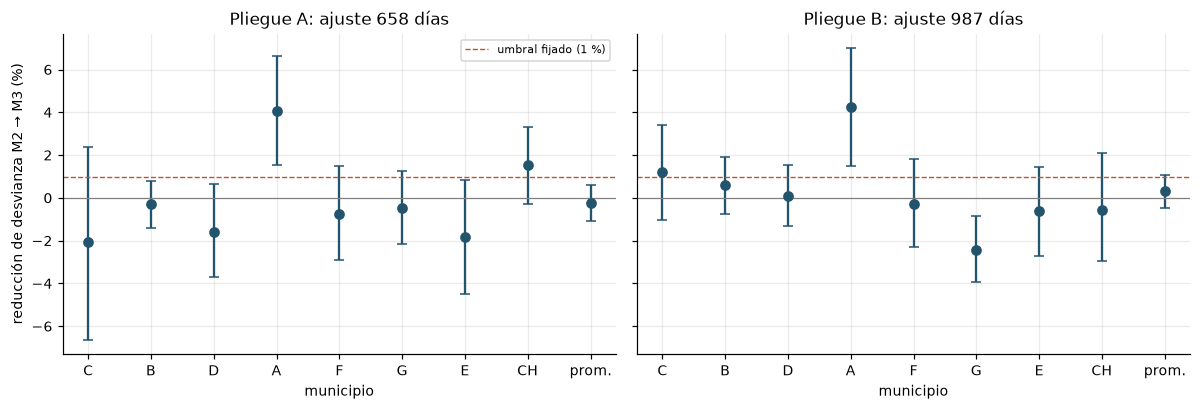

In [24]:
# Regla fijada antes de ejecutar: un municipio "necesita su propio calendario" si, en los DOS pliegues,
# M3 mejora a M2 en >= UMBRAL_DESV_REL de desvianza y el IC95 de la diferencia excluye 0 a favor de M3.
m23 = pareadas[(pareadas["comparación"] == "M2 → M3") & (pareadas["municipio"].isin(ORDEN))].copy()
m23["ok"] = (m23["reducción relativa (%)"] >= 100 * UMBRAL_DESV_REL) & (m23["IC95 inf"] > 0)
cumple = m23.pivot(index="municipio", columns="pliegue", values="ok").reindex(ORDEN)
decision = pd.DataFrame({
    "cumple en pliegue A": cumple["A"], "cumple en pliegue B": cumple["B"],
    "necesita calendario propio (A y B)": cumple["A"] & cumple["B"],
})
decision.index.name = "municipio"
guardar_tabla(decision.reset_index(), "21_regla_de_decision")
print(f"municipios que necesitan calendario propio según la regla: {int(decision['necesita calendario propio (A y B)'].sum())} de {len(ORDEN)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, nombre in zip(axes, PLIEGUES):
    sel = pareadas[(pareadas["pliegue"] == nombre) & (pareadas["comparación"] == "M2 → M3")].set_index("municipio")
    base = {m: dev_diaria[nombre]["M2"][m].mean() for m in ORDEN}
    base["promedio de los 8"] = float(np.mean([base[m] for m in ORDEN]))
    xs = list(ORDEN) + ["promedio de los 8"]
    val = np.array([100 * sel.loc[m, "Δ desvianza (a − b)"] / base[m] for m in xs])
    lo = np.array([100 * sel.loc[m, "IC95 inf"] / base[m] for m in xs])
    hi = np.array([100 * sel.loc[m, "IC95 sup"] / base[m] for m in xs])
    ax.errorbar(range(len(xs)), val, yerr=[val - lo, hi - val], fmt="o", color="#22546e", capsize=3)
    ax.axhline(0, color="grey", lw=0.8)
    ax.axhline(100 * UMBRAL_DESV_REL, color="#c0542f", ls="--", lw=0.9, label="umbral fijado (1 %)")
    ax.set_xticks(range(len(xs))); ax.set_xticklabels(ORDEN + ["prom."])
    ax.set_title(f"Pliegue {nombre}: ajuste {PLIEGUES[nombre]} días"); ax.set_xlabel("municipio")
axes[0].set_ylabel("reducción de desvianza M2 → M3 (%)"); axes[0].legend(fontsize=7.5)
fig.tight_layout(); guardar_figura(fig, "fig6_calendario_propio_vs_agregado")
plt.show()

**Evidencia (tablas `18`, `20`, `21`; figura `fig6`).** Desvianza media de los 8 en validación:

| | M0 | M1 | M2 | M3 | M4 | M5 |
| --- | --- | --- | --- | --- | --- | --- |
| Pliegue A | 1,3897 | 1,3291 | 1,2278 | 1,2305 | 1,3614 | 1,2302 |
| Pliegue B | 1,4014 | 1,3441 | 1,2385 | 1,2344 | 1,3791 | 1,2420 |

Diferencias pareadas, promedio de los 8 (IC95 por bootstrap de bloques; una reducción es positiva si el
segundo modelo es mejor):

| Comparación | Pliegue A | Pliegue B |
| --- | --- | --- |
| M0 → M1 (calendario común) | +4,36 % (IC excluye 0) | +4,09 % (IC excluye 0) |
| M1 → M2 (**nivel propio**) | **+7,62 %** (IC excluye 0) | **+7,86 %** (IC excluye 0) |
| M2 → M3 (**calendario propio**) | −0,22 % (IC −0,0132 a 0,0072) | +0,32 % (IC −0,0056 a 0,0134) |
| M5 → M3 (forma prestada vs. propia) | −0,03 % | +0,61 % (IC −0,0032 a 0,0181) |
| M4 → M2 (municipio sin datos propios) | **+9,81 %** (IC excluye 0) | **+10,20 %** (IC excluye 0) |

**Por municipio, M2 → M3:** sólo **A** tiene el IC por encima de 0 en los dos pliegues (**+4,06 %** y
**+4,24 %**). **G** empeora de forma significativa con calendario propio en el pliegue B (−2,45 %,
IC −0,0472 a −0,0099). **C** (−2,05 % y +1,22 %) y **CH** (+1,53 % y −0,56 %) **cambian de signo entre
pliegues** y sus IC incluyen 0 en ambos, aunque la sección 7.1b los marcaba como distintos en muestra.

**Resultado de la regla:** **1 de 8 municipios (A) necesita su propio calendario**; los otros siete
quedan bien servidos por el calendario común.

**Inferencia del equipo:**

1. **Lo que más separa a los municipios es el nivel, no la forma.** Saber el nivel del municipio mejora
   ~7,6–7,9 %; un municipio sin datos propios (M4) cuesta ~10 % frente a uno con nivel propio. Es
   exactamente el bloque de variables que ya había identificado el diagnóstico principal (tasa
   histórica del municipio, −7,5 % fuera de muestra) y que el panel todavía no incluye.
2. **Un calendario común alcanza para siete de los ocho.** En promedio, especializar el calendario no
   mejora (−0,22 % y +0,32 %, ICs que incluyen 0) y **puede empeorar** (G): con 658–987 días de ajuste
   y 8 grupos de calendario, el perfil propio estima ruido. Que C y CH sean distintos *en muestra* y no
   ganen *fuera de muestra* ilustra que **detectable no es explotable**.
3. **A es la excepción reproducible.** Gana ~4 % en ambos pliegues, y prestarle la forma de los otros
   siete le cuesta ~5 %. Su perfil sabatino (sección 4.1) y su pendiente mayor en el desarrollo (sección 3; no se reproduce con sólo el entrenamiento: ver 7.6) apuntan en la
   misma dirección.
4. **Un solo modelo con una variable de nivel por municipio es la primera hipótesis a probar;** modelos
   separados por municipio **no están respaldados** por estos datos, con la posible excepción de A, y
   eso se resuelve primero con un término propio para A dentro del modelo común, no con un modelo aparte.

### 7.4 Calibración de nivel: la razón total predicho/observado

Con el nivel fijado en el pasado, cada pliegue valida un período en que la serie ya creció. La razón
total predicho/observado de M2 muestra cuánto se queda corto el nivel y si lo hace por igual.

In [25]:
# Razón total predicho/observado de M2 en cada pliegue: si la tendencia afecta distinto a cada municipio, aparece acá.
rz = (met[met["modelo"] == "M2"].pivot_table(index="municipio", columns="pliegue", values="razón total pred./obs.")
      .reindex(ORDEN).round(3))
rango = pd.DataFrame({"A": [f"{rz['A'].min():.3f}–{rz['A'].max():.3f}"], "B": [f"{rz['B'].min():.3f}–{rz['B'].max():.3f}"]},
                     index=["(rango entre municipios)"])
rz_tab = pd.concat([rz.astype(str), rango]).rename_axis("municipio").reset_index()
guardar_tabla(rz_tab, "22_razon_total_M2_por_municipio")

[tabla]  experiments\diagnostico_municipios\tablas\22_razon_total_M2_por_municipio.csv


,municipio,A,B
0,C,0.978,0.9
1,B,0.94,0.997
2,D,0.965,0.945
3,A,0.927,0.842
4,F,0.903,0.865
5,G,0.902,0.906
6,E,1.086,0.911
7,CH,0.968,1.007
8,(rango entre municipios),0.902–1.086,0.842–1.007


**Evidencia (tabla `22`):** en el pliegue A la razón va de **0,902 a 1,086** y en el B de **0,842 a 1,007**.
En el pliegue B, **A es el que más se queda corto (0,842)**, seguido de F (0,865) y C (0,900); CH queda
calibrado (1,007).

**Inferencia:** la tendencia creciente hace que **el nivel histórico subestime en casi todos**, pero
**no por igual**: entre ~0 % y ~16 % de subestimación según el municipio. Es coherente con que A tenga
la pendiente más alta del desarrollo (sección 3; con sólo el entrenamiento no es mayor, ver 7.6), pero no es una medición de esa causa. Para el modelado significa que
**la variable de nivel por municipio debe poder actualizarse o recalibrarse** (por ejemplo con una
ventana reciente), no sólo estimarse una vez.

### 7.5 Aporte de cada bloque de variables, fuera de muestra

Mide cuánto aporta cada bloque de información (calendario, tasa del municipio, lluvia) y justifica la
forma de la línea de referencia multiplicativa. Mismo esquema que 7.2: dos pliegues cronológicos dentro del
**desarrollo**, todos los predictores estimados **sólo con el ajuste** y evaluados en la validación
(el test no interviene). Cada bloque se compara contra la constante global; el IC95 es el del bootstrap por
bloques semanales de la sección 7.2.

| Bloque | Predictor |
| --- | --- |
| B0 | constante global |
| B1 | sólo calendario (día de la semana + feriado) |
| B2 | sólo tasa del municipio |
| B3 | tasa × calendario (= M2) |
| B4 | tasa × calendario × factor de lluvia (calibración multiplicativa estimada en el ajuste) |
| B5 | celdas municipio × calendario (= M3) |
| B6 | celdas saturadas municipio × calendario × mes (celda vacía: cae a B3; piso de 1e-6 en la predicción, como en el resto del proyecto) |

Además se mide la **deriva del nivel** entre el ajuste y la validación y se descompone la varianza del
desarrollo (en muestra, descriptiva: no es un resultado de predicción). **No se recalculan los «techos en
muestra»** del diagnóstico anterior: evaluar con los mismos datos con que se ajusta no informa ninguna decisión.

[tabla]  experiments\diagnostico_municipios\tablas\23_aporte_bloques_fuera_de_muestra.csv


,pliegue,bloque,predictor (estimado sólo con el ajuste),parámetros libres (aprox.),desvianza media,mejora vs constante (%),IC95 de la mejora (%)
0,A,B0,constante global,1,1.3897,0.00,[0.00; 0.00]
1,A,B1,sólo calendario (día de la semana + feriado),8,1.3291,4.36,[3.07; 5.62]
2,A,B2,sólo tasa del municipio,8,1.2885,7.28,[5.54; 9.07]
3,A,B3,"tasa del municipio × calendario (= M2, línea ...",16,1.2278,11.65,[9.29; 13.84]
4,A,B4,tasa × calendario × efecto de la lluvia,18,1.2323,11.33,[8.94; 13.49]
5,A,B5,celdas municipio × calendario (= M3),64,1.2305,11.45,[9.06; 13.77]
6,A,B6,celdas saturadas municipio × calendario × mes,hasta 768,1.4958,-7.64,[-17.29; 0.02]
7,B,B0,constante global,1,1.4014,0.00,[0.00; 0.00]
8,B,B1,sólo calendario (día de la semana + feriado),8,1.3441,4.09,[2.67; 5.51]
9,B,B2,sólo tasa del municipio,8,1.2958,7.54,[5.56; 9.55]


celdas ocupadas de B6 (de 8×8×12 = 768 posibles): {'A': 760, 'B': 760}
[tabla]  experiments\diagnostico_municipios\tablas\23b_comparaciones_entre_bloques.csv


,pliegue,comparación,reducción relativa (%),IC95 inf (%),IC95 sup (%),el IC excluye 0
0,A,B3 → B4 (agregar lluvia),-0.36,-0.65,-0.07,True
1,A,B3 → B6 (saturar con el mes),-21.83,-32.83,-13.20,True
2,A,B2 → B3 (agregar calendario a la tasa),4.71,3.31,6.07,True
3,B,B3 → B4 (agregar lluvia),-0.01,-0.14,0.11,False
4,B,B3 → B6 (saturar con el mes),-16.90,-32.84,-6.23,True
5,B,B2 → B3 (agregar calendario a la tasa),4.42,2.89,5.96,True


[tabla]  experiments\diagnostico_municipios\tablas\24_deriva_entre_ajuste_y_validacion.csv


,pliegue,"media diaria por municipio, ajuste","media diaria por municipio, validación",cambio (%)
0,A,2.6081,2.7394,5.03
1,B,2.6518,2.8860,8.83


[tabla]  experiments\diagnostico_municipios\tablas\25_descomposicion_varianza.csv


,fuente de variación,% de la varianza total del desarrollo
0,entre municipios,7.71
1,entre días (media de los 8 municipios por día),18.04
2,"de lo anterior, esperable por puro azar de P...",11.54
3,"exceso sobre el azar (efecto de día real, cota)",6.50


[figura] experiments\diagnostico_municipios\figuras\fig7_aporte_bloques.png


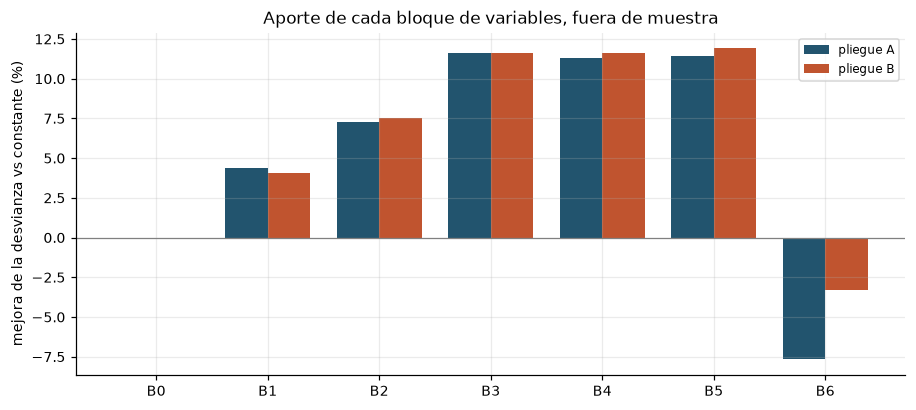

In [26]:
BLOQUES = {
    "B0": ("constante global", "1"),
    "B1": ("sólo calendario (día de la semana + feriado)", "8"),
    "B2": ("sólo tasa del municipio", "8"),
    "B3": ("tasa del municipio × calendario  (= M2, línea de referencia)", "16"),
    "B4": ("tasa × calendario × efecto de la lluvia", "18"),
    "B5": ("celdas municipio × calendario  (= M3)", "64"),
    "B6": ("celdas saturadas municipio × calendario × mes", "hasta 768"),
}


def predecir_bloques(Y_aj, g_aj, ll_aj, idx_val):
    """Predicciones de cada bloque para idx_val, estimadas sólo con Y_aj (días de ajuste)."""
    muns = list(Y_aj.columns)
    gv = grupo.loc[idx_val].to_numpy(); mv = idx_val.month.to_numpy(); lv = llovio.loc[idx_val].to_numpy()
    media = Y_aj.mean()
    f_agg = factor_calendario(Y_aj.sum(axis=1), g_aj)
    m2_aj = pd.DataFrame({m: media[m] * f_agg.reindex(g_aj.to_numpy()).to_numpy() for m in muns}, index=Y_aj.index)
    ll = ll_aj.to_numpy()
    f_ll = {l: Y_aj.to_numpy()[ll == l].sum() / m2_aj.to_numpy()[ll == l].sum() for l in (0, 1)}   # calibra M2 por lluvia, sólo en ajuste
    mes_aj = Y_aj.index.month
    pred = {k: pd.DataFrame(index=idx_val, columns=muns, dtype=float) for k in BLOQUES}
    celdas = 0
    for m in muns:
        m2v = media[m] * f_agg.reindex(gv).to_numpy()
        pred["B0"][m] = Y_aj.to_numpy().mean()
        pred["B1"][m] = Y_aj.to_numpy().mean() * f_agg.reindex(gv).to_numpy()
        pred["B2"][m] = media[m]
        pred["B3"][m] = m2v
        pred["B4"][m] = m2v * np.array([f_ll[int(l)] for l in lv])
        pred["B5"][m] = media[m] * factor_calendario(Y_aj[m], g_aj).reindex(gv).to_numpy()
        cel = Y_aj[m].groupby([g_aj.to_numpy(), mes_aj]).mean()
        celdas += len(cel)
        valores = np.array([cel.get((g, mm), np.nan) for g, mm in zip(gv, mv)], dtype=float)
        pred["B6"][m] = np.clip(np.where(np.isnan(valores), m2v, valores), 1e-6, None)   # celda vacía: cae a B3; piso 1e-6 como en el proyecto
    return pred, celdas


dev_b, filas, celdas_ocupadas = {}, [], {}
for nombre, n_aj in PLIEGUES.items():
    ini, fin = n_aj, n_aj + N_VAL
    assert fin <= N_DES, "la validación invadiría el bloque final"
    Y_aj, Y_val = y.iloc[:n_aj], y.iloc[ini:fin]
    pred, celdas_ocupadas[nombre] = predecir_bloques(Y_aj, grupo.iloc[:n_aj], llovio.iloc[:n_aj], Y_val.index)
    dev_b[nombre] = {k: pd.DataFrame(desvianza_diaria(Y_val.to_numpy(), p.to_numpy()), index=Y_val.index, columns=ORDEN)
                     for k, p in pred.items()}
    base = dev_b[nombre]["B0"].to_numpy().mean()
    for k, (desc, par) in BLOQUES.items():
        d = dev_b[nombre][k].to_numpy().mean()
        dif = bootstrap_diferencia(dev_b[nombre]["B0"], dev_b[nombre][k])["promedio de los 8"]
        filas.append({"pliegue": nombre, "bloque": k, "predictor (estimado sólo con el ajuste)": desc,
                      "parámetros libres (aprox.)": par, "desvianza media": round(d, 4),
                      "mejora vs constante (%)": round(100 * (base - d) / base, 2),
                      "IC95 de la mejora (%)": f"[{100 * dif[1] / base:.2f}; {100 * dif[2] / base:.2f}]"})
aporte = pd.DataFrame(filas)
guardar_tabla(aporte, "23_aporte_bloques_fuera_de_muestra")
print("celdas ocupadas de B6 (de 8×8×12 = 768 posibles):", celdas_ocupadas)

comp = []
for nombre in PLIEGUES:
    for etq, a, b in (("B3 → B4 (agregar lluvia)", "B3", "B4"), ("B3 → B6 (saturar con el mes)", "B3", "B6"), ("B2 → B3 (agregar calendario a la tasa)", "B2", "B3")):
        medio, lo, hi = bootstrap_diferencia(dev_b[nombre][a], dev_b[nombre][b])["promedio de los 8"]
        ref = dev_b[nombre][a].to_numpy().mean()
        comp.append({"pliegue": nombre, "comparación": etq, "reducción relativa (%)": round(100 * medio / ref, 2),
                     "IC95 inf (%)": round(100 * lo / ref, 2), "IC95 sup (%)": round(100 * hi / ref, 2),
                     "el IC excluye 0": bool(lo > 0 or hi < 0)})
guardar_tabla(pd.DataFrame(comp), "23b_comparaciones_entre_bloques")

# Deriva del nivel entre el ajuste y la validación (todos los predictores quedan estimados sobre el tramo previo)
filas = []
for nombre, n_aj in PLIEGUES.items():
    m_aj, m_val = y.iloc[:n_aj].to_numpy().mean(), y.iloc[n_aj:n_aj + N_VAL].to_numpy().mean()
    filas.append({"pliegue": nombre, "media diaria por municipio, ajuste": round(m_aj, 4),
                  "media diaria por municipio, validación": round(m_val, 4), "cambio (%)": round(100 * (m_val / m_aj - 1), 2)})
guardar_tabla(pd.DataFrame(filas), "24_deriva_entre_ajuste_y_validacion")

# Descomposición de la varianza del desarrollo, en muestra y descriptiva (no es un resultado de predicción)
yy = y.to_numpy(float)
tot = yy.var()
f_mun = yy.mean(axis=0).var() / tot
f_dia = yy.mean(axis=1).var() / tot
f_azar = (1 - f_mun) / len(ORDEN)   # lo que daría la media de 8 municipios independientes por día aunque el día no tuviera ningún efecto
descomp = pd.DataFrame([
    ("entre municipios", round(100 * f_mun, 2)),
    ("entre días (media de los 8 municipios por día)", round(100 * f_dia, 2)),
    ("  de lo anterior, esperable por puro azar de Poisson (≈ (1 − entre municipios) ÷ 8)", round(100 * f_azar, 2)),
    ("  exceso sobre el azar (efecto de día real, cota)", round(100 * (f_dia - f_azar), 2)),
], columns=["fuente de variación", "% de la varianza total del desarrollo"])
guardar_tabla(descomp, "25_descomposicion_varianza")

fig, ax = plt.subplots(figsize=(8.4, 3.8))
ks = list(BLOQUES)
ancho = 0.38
for i, nombre in enumerate(PLIEGUES):
    v = aporte[aporte["pliegue"] == nombre].set_index("bloque").loc[ks, "mejora vs constante (%)"].to_numpy()
    ax.bar(np.arange(len(ks)) + (i - 0.5) * ancho, v, ancho, label=f"pliegue {nombre}", color=["#22546e", "#c0542f"][i])
ax.axhline(0, color="grey", lw=0.8); ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks)
ax.set_ylabel("mejora de la desvianza vs constante (%)"); ax.set_title("Aporte de cada bloque de variables, fuera de muestra")
ax.legend(fontsize=8); fig.tight_layout(); guardar_figura(fig, "fig7_aporte_bloques")
plt.show()

**Evidencia (tablas `23`, `23b`, `24`, `25`; figura `fig7`).** Mejora de la desvianza media de los 8
respecto de la constante (positivo = mejor), con IC95 entre corchetes:

| Bloque | Pliegue A | Pliegue B |
| --- | --- | --- |
| B1 sólo calendario | +4,36 % [3,07; 5,62] | +4,09 % [2,67; 5,51] |
| B2 sólo tasa del municipio | +7,28 % [5,54; 9,07] | +7,54 % [5,56; 9,55] |
| **B3 tasa × calendario** | **+11,65 %** [9,29; 13,84] | **+11,63 %** [9,45; 13,71] |
| B4 + lluvia | +11,33 % [8,94; 13,49] | +11,61 % [9,41; 13,73] |
| B5 municipio × calendario | +11,45 % [9,06; 13,77] | +11,91 % [9,48; 14,23] |
| B6 celdas saturadas con el mes | **−7,64 %** [−17,29; 0,02] | **−3,31 %** [−18,08; 6,86] |

Comparaciones entre bloques (`23b`): agregar el calendario a la tasa (B2 → B3) mejora **+4,71 %** y **+4,42 %**
(IC excluye 0 en ambos); agregar la lluvia (B3 → B4) **no mejora** (−0,36 % con IC −0,65 a −0,07, y −0,01 % con
IC que incluye 0); saturar con el mes (B3 → B6) **empeora −21,83 % y −16,90 %** (IC excluye 0). B6 ocupa
760 de las 768 celdas posibles. **Deriva del nivel** (`24`): la media diaria por municipio sube **5,03 %** (A)
y **8,83 %** (B) de ajuste a validación. **Varianza del desarrollo** (`25`): **7,71 %** entre municipios y
**18,04 %** entre días; de esto último, **≈ 11,54 %** es lo que produciría el puro azar de Poisson al
promediar 8 municipios por día aunque el día no tuviera efecto, así que el exceso atribuible al día es a
lo sumo **6,50 %**.

**Inferencia del equipo:**

1. **La tasa del municipio aporta más que el calendario** (7,3–7,5 % contra 4,1–4,4 %), aun con 8 parámetros
   contra 8, y **la combinación multiplicativa es la mejor** (≈ 11,6 %): mejora a cada bloque por separado
   con IC que excluye 0. Es la forma de la línea de referencia (tasa × calendario), ahora medida **sólo con
   desarrollo**.
2. **La lluvia no aporta**: mantenerla exige otra justificación que «estaba disponible». (Se midió un
   único efecto binario, `llovió`; no se descarta que otra forma de usar el clima aporte algo.)
3. **Saturar el modelo con celdas independientes memoriza ruido**: queda **peor que no usar nada**. Justifica
   la forma multiplicativa y desaconseja cruzar municipio y calendario sin restricciones.
4. **La variación entre días (18 %) no contradice lo anterior:** casi dos tercios de esa cifra es ruido de
   Poisson compartido, no señal predecible, y por eso el calendario recupera sólo una fracción pequeña.
5. **El nivel sube entre el ajuste y la validación** (+5 % a +9 %), así que todos los predictores
   subestiman y **las mejoras informadas son conservadoras**. Coincide con la sección 7.4 y apoya recalibrar
   el nivel.

*Frase que estos datos NO sostienen:* «el clima no sirve para predecir siniestros» (sólo se midió el
indicador `llovió`, a resolución diaria y agregado por municipio).

**Qué se retiró del diagnóstico anterior y cómo se compara.** Las cifras de este bloque **no son comparables**
con las del diagnóstico retirado (que partía el período completo, test incluido, a la mitad): es otro
protocolo y otro período. La conclusión cualitativa coincide: tasa > calendario, la combinación
multiplicativa es la mejor, la lluvia no aporta y las celdas saturadas empeoran.

### 7.6 Estabilidad entre ventanas: los diagnósticos que orientan decisiones, con sólo el entrenamiento inicial

Las secciones 3, 4.1, 4.2, 5.1, 5.2 y 7.1 se calculan sobre todo el desarrollo, validación incluida, algo que el docente
confirmó como válido. Aun así, como orientan decisiones de modelado, se repiten acá con **sólo los 987 días de
entrenamiento inicial** (2021-07-01 → 2024-03-13) para ver **cuánto dependen de incluir la validación**: tendencia (por
municipio y del agregado), perfil semanal, pruebas de homogeneidad, transformación del objetivo y memoria (Ljung-Box sobre
el residuo). Si una conclusión se mantiene, es estable entre ventanas; si cambia, **se declara**.

In [27]:
# 7.6 — Los diagnósticos que orientan decisiones de modelado, repetidos con SÓLO el entrenamiento inicial
# (987 días, 2021-07-01 → 2024-03-13): ni la ventana de validación ni el test participan.
tr = slice(0, N_AJ)
n_tr = N_AJ

# (a) Tendencia por municipio y del agregado
filas = []
dagg_tr = pd.DataFrame({"y": y.sum(axis=1).iloc[tr], "grupo": grupo.iloc[tr], "t": t_anios.iloc[tr]})
ag_tr = smf.glm("y ~ C(grupo) + t", dagg_tr, family=sm.families.Poisson()).fit(scale="X2")
pend_ag_tr = 100 * (np.exp(ag_tr.params["t"]) - 1)
for m in ORDEN:
    d = pd.DataFrame({"y": y[m].iloc[tr], "grupo": grupo.iloc[tr], "t": t_anios.iloc[tr]})
    aj = smf.glm("y ~ C(grupo) + t", d, family=sm.families.Poisson()).fit(scale="X2")
    lo_, hi_ = aj.conf_int().loc["t"]
    p_dev = pend.set_index("municipio").loc[m]
    filas.append({"municipio": m,
                  "pendiente entrenamiento (%/año)": round(100 * (np.exp(aj.params["t"]) - 1), 2),
                  "IC95 entrenamiento": f"[{100 * (np.exp(lo_) - 1):.2f}; {100 * (np.exp(hi_) - 1):.2f}]",
                  "p entrenamiento": float(f"{aj.pvalues['t']:.3g}"),
                  "detectable (p<0,05) entrenamiento": bool(aj.pvalues["t"] < 0.05),
                  "pendiente desarrollo (%/año)": p_dev["pendiente (%/año)"],
                  "detectable (p<0,05) desarrollo": bool(p_dev["p"] < 0.05)})
rob_tend = pd.DataFrame(filas)
guardar_tabla(rob_tend, "25b_robustez_tendencia")
print(f"pendiente del agregado: entrenamiento {pend_ag_tr:.2f} %/año · desarrollo {PEND_AGREGADA:.2f} %/año")

# (b) Perfil semanal
perf_tr = pd.DataFrame({m: y[m].iloc[tr].groupby(grupo.iloc[tr]).mean().reindex(GRUPOS) / y[m].iloc[tr].mean() for m in ORDEN}).T
sem_tr = perf_tr[ORDEN_SEMANA]
filas = []
for m in ORDEN:
    filas.append({"municipio": m,
                  "sábado (entrenamiento)": round(perf_tr.loc[m, "sábado"], 3),
                  "sábado (desarrollo)": round(perfil.loc[m, "sábado"], 3),
                  "vie ÷ dom (entrenamiento)": round(perf_tr.loc[m, "viernes"] / perf_tr.loc[m, "domingo"], 2),
                  "vie ÷ dom (desarrollo)": resumen_sem.loc[m, "viernes ÷ domingo"],
                  "correlación con el agregado (entrenamiento)": round(np.corrcoef(sem_tr.loc[m], sem_tr.mean())[0, 1], 3),
                  "correlación con el agregado (desarrollo)": resumen_sem.loc[m, "correlación con el perfil del agregado"]})
rob_perfil = pd.DataFrame(filas)
guardar_tabla(rob_perfil, "25c_robustez_perfil_semanal")

# (c) Pruebas de homogeneidad
largo_tr = pd.DataFrame({
    "y": y.iloc[tr].to_numpy().ravel(), "mun": np.tile(np.array(ORDEN), n_tr),
    "grupo": np.repeat(grupo.iloc[tr].to_numpy(), len(ORDEN)), "mes": np.repeat(DIAS[tr].month.to_numpy(), len(ORDEN)),
    "t": np.repeat(t_anios.iloc[tr].to_numpy(), len(ORDEN)), "llovio": np.repeat(llovio.iloc[tr].to_numpy(), len(ORDEN))})
assert len(largo_tr) == n_tr * len(ORDEN) and DIAS[tr][-1] < DIAS[N_AJ]
filas = []
for nombre, nula, alt in PRUEBAS:
    r_ = prueba_cuasi_f(nula, alt, largo_tr)
    d_ = homog.set_index("hipótesis alternativa").loc[nombre]
    filas.append({"hipótesis alternativa": nombre, "F entrenamiento": r_["F"], "p entrenamiento": r_["p"],
                  "reducción de desvianza (%) entrenamiento": r_["reducción de desvianza (%)"],
                  "p desarrollo": d_["p"], "reducción (%) desarrollo": d_["reducción de desvianza (%)"]})
rob_homog = pd.DataFrame(filas)
guardar_tabla(rob_homog, "25d_robustez_homogeneidad")

# (d) Transformación del objetivo
filas = []
for m in ORDEN:
    v = y[m].iloc[tr].to_numpy(float)
    t_dev = transf.set_index("municipio").loc[m]
    filas.append({"municipio": m, "λ Box-Cox entrenamiento": round(sps.boxcox(v + 1)[1], 3), "λ Box-Cox desarrollo": t_dev["λ Box-Cox (MLE, serie+1)"],
                  "r1 con d=1 entrenamiento": round(acf(np.diff(v), nlags=1)[1], 3), "r1 con d=1 desarrollo": t_dev["ACF r1 tras diferenciar (d=1)"],
                  "ADF p entrenamiento": float(f"{adfuller(v, autolag='AIC')[1]:.3g}"),
                  "KPSS p entrenamiento": round(kpss(v, regression="c", nlags="auto")[1], 3)})
rob_transf = pd.DataFrame(filas)
guardar_tabla(rob_transf, "25e_robustez_transformacion")

# (e) Memoria: Ljung-Box sobre el residuo de calendario (entrenamiento)
filas = []
for m in ORDEN:
    v = y[m].iloc[tr].to_numpy(float)
    res = v - y[m].iloc[tr].groupby(grupo.iloc[tr]).transform("mean").to_numpy()
    lb = acorr_ljungbox(res, lags=[7, 14, 28])["lb_pvalue"]
    a_dev = acf_tab.set_index("municipio").loc[m]
    filas.append({"municipio": m, "Ljung-Box p (7) entrenamiento": float(f"{lb.iloc[0]:.3g}"), "p (14) entrenamiento": float(f"{lb.iloc[1]:.3g}"),
                  "p (28) entrenamiento": float(f"{lb.iloc[2]:.3g}"),
                  "rechaza en algún horizonte (entrenamiento)": bool((lb < 0.05).any()),
                  "rechaza en algún horizonte (desarrollo)": bool((a_dev[["Ljung-Box p (7)", "Ljung-Box p (14)", "Ljung-Box p (28)"]] < 0.05).any())})
rob_mem = pd.DataFrame(filas)
guardar_tabla(rob_mem, "25f_robustez_memoria")

[tabla]  experiments\diagnostico_municipios\tablas\25b_robustez_tendencia.csv


,municipio,pendiente entrenamiento (%/año),IC95 entrenamiento,p entrenamiento,"detectable (p<0,05) entrenamiento",pendiente desarrollo (%/año),"detectable (p<0,05) desarrollo"
0,C,-0.55,[-4.97; 4.08],0.8120,False,3.17,True
1,B,5.23,[0.42; 10.28],0.0328,True,2.33,False
2,D,2.96,[-1.89; 8.05],0.2360,False,2.77,False
3,A,3.89,[-1.12; 9.16],0.1300,False,7.34,True
4,F,6.07,[0.75; 11.68],0.0249,True,7.04,True
5,G,6.20,[0.39; 12.35],0.0360,True,5.50,True
6,E,-3.73,[-9.33; 2.21],0.2130,False,1.02,False
7,CH,0.19,[-5.60; 6.34],0.9500,False,-0.07,False


pendiente del agregado: entrenamiento 2.61 %/año · desarrollo 3.72 %/año
[tabla]  experiments\diagnostico_municipios\tablas\25c_robustez_perfil_semanal.csv


,municipio,sábado (entrenamiento),sábado (desarrollo),vie ÷ dom (entrenamiento),vie ÷ dom (desarrollo),correlación con el agregado (entrenamiento),correlación con el agregado (desarrollo)
0,C,0.885,0.897,2.23,2.19,0.993,0.992
1,B,0.907,0.883,1.61,1.58,0.967,0.972
2,D,0.951,0.896,1.48,1.45,0.982,0.975
3,A,1.111,1.143,1.54,1.43,0.769,0.609
4,F,0.967,0.916,1.47,1.44,0.902,0.953
5,G,1.003,0.991,1.39,1.41,0.868,0.962
6,E,0.829,0.853,1.95,1.88,0.923,0.959
7,CH,0.890,0.865,1.85,1.79,0.929,0.954


[tabla]  experiments\diagnostico_municipios\tablas\25d_robustez_homogeneidad.csv


,hipótesis alternativa,F entrenamiento,p entrenamiento,reducción de desvianza (%) entrenamiento,p desarrollo,reducción (%) desarrollo
0,nivel propio por municipio,98.31,2.930000e-138,7.360,2.060000e-190,7.545
1,perfil de calendario distinto por municipio,2.08,1.630000e-05,1.165,1.460000e-09,1.139
2,tendencia distinta por municipio,1.63,1.230000e-01,0.131,3.250000e-02,0.132
3,estacionalidad anual distinta por municipio,1.32,3.250000e-02,1.169,1.560000e-02,0.919
4,efecto de la lluvia distinto por municipio,1.15,3.300000e-01,0.093,3.540000e-01,0.067


[tabla]  experiments\diagnostico_municipios\tablas\25e_robustez_transformacion.csv


,municipio,λ Box-Cox entrenamiento,λ Box-Cox desarrollo,r1 con d=1 entrenamiento,r1 con d=1 desarrollo,ADF p entrenamiento,KPSS p entrenamiento
0,C,0.434,0.448,-0.459,-0.464,1.160000e-09,0.100
1,B,0.497,0.497,-0.521,-0.513,0.000000e+00,0.077
2,D,0.377,0.409,-0.496,-0.486,0.000000e+00,0.100
3,A,0.457,0.461,-0.504,-0.493,0.000000e+00,0.100
4,F,0.416,0.420,-0.462,-0.477,0.000000e+00,0.037
5,G,0.403,0.419,-0.543,-0.549,0.000000e+00,0.063
6,E,0.254,0.251,-0.458,-0.470,9.300000e-15,0.100
7,CH,0.250,0.257,-0.500,-0.484,5.020000e-13,0.100


[tabla]  experiments\diagnostico_municipios\tablas\25f_robustez_memoria.csv


,municipio,Ljung-Box p (7) entrenamiento,p (14) entrenamiento,p (28) entrenamiento,rechaza en algún horizonte (entrenamiento),rechaza en algún horizonte (desarrollo)
0,C,0.068900,0.147000,0.36400,False,True
1,B,0.119000,0.142000,0.44400,False,True
2,D,0.582000,0.053500,0.12500,False,True
3,A,0.808000,0.850000,0.92100,False,False
4,F,0.249000,0.361000,0.22600,False,False
5,G,0.273000,0.644000,0.91800,False,False
6,E,0.755000,0.187000,0.12700,False,False
7,CH,0.000553,0.000756,0.00902,True,True


**Evidencia (tablas `25b` a `25f`):**

| Conclusión | Con sólo el entrenamiento | Veredicto |
| --- | --- | --- |
| El **nivel** difiere entre municipios | F = 98,31; reduce 7,36 % la desvianza (desarrollo: 134,47; 7,545 %) | **Se sostiene** |
| El **perfil de calendario** difiere | F = 2,08; p = 1,6·10⁻⁵; 1,165 % (desarrollo: 2,71; 1,139 %) | **Se sostiene** |
| **A** tiene el sábado alto | sábado **1,111** (desarrollo 1,143); correlación con el agregado **0,769** (0,609); el siguiente es G con 1,003 | **Se sostiene** (en G el sábado es ≈ 1) |
| Calendario propio de A mejora la predicción | pliegue A (validación **dentro** del entrenamiento): **+4,06 %**, IC excluye 0 | **Se sostiene** |
| La **lluvia** no cambia por municipio | p = 0,33 (0,35) | **Se sostiene** |
| **No diferenciar ni transformar** | λ de Box-Cox 0,25–0,50 (igual que en el desarrollo); r1 con d = 1 de −0,46 a −0,54; ADF rechaza en los 8; KPSS rechaza sólo en F | **Se sostiene** |
| **Tendencia distinta por municipio** | p = 0,123 y 0,131 % de desvianza (desarrollo: 0,033 y 0,132 %) | **No concluyente** |
| **A tiene la pendiente mayor** | A: 3,89 %/año [−1,12; 9,16], p = 0,13; agregado 2,61 %/año. Con el desarrollo: 7,34 % contra 3,72 % | **No se sostiene**: depende de la ventana de validación |
| Tendencia **detectable** en C, A, F y G | Con el entrenamiento: sólo **B (5,23), F (6,07) y G (6,20)** | **Cambia** |
| **C y CH** tienen memoria | Ljung-Box (7 / 14 / 28): **CH** rechaza (0,0006; 0,0008; 0,009); **C no** (0,069; 0,147; 0,364) | **Se sostiene sólo para CH** |
| Estacionalidad anual distinta | p = 0,033 y 1,17 % (desarrollo: 0,016 y 0,92 %) | **No concluyente** (igual que antes) |

**Inferencia del equipo.** La **conclusión central se sostiene** sin mirar la validación: el nivel domina, el
calendario común sirve salvo en A, el sábado de A es real y no hay que transformar el objetivo. Se **debilitan dos
afirmaciones secundarias**: que A tenga la pendiente más empinada (aparece sólo al incluir la validación; en
entrenamiento no se distingue del agregado) y que C tenga memoria de corto plazo (también aparece con la validación).
**Las cifras del desarrollo son válidas y citables; conviene citar ambas con la mención de que son sensibles a incluir la validación.**
Además, la tendencia, que en el desarrollo parecía distinta entre municipios, deja de serlo con menos datos: **no hay
evidencia sostenible de una tendencia específica por municipio**.

## 8. Síntesis: ¿puede un solo modelo generalizar?

| Aspecto | ¿Homogéneo entre los 8? | Evidencia principal | Consecuencia para el modelado |
| --- | --- | --- | --- |
| Calidad de la serie | **Sí** | cobertura completa; ceros y dispersión explicados por la media (2.1) | un mismo tratamiento del objetivo |
| **Nivel** | **No** (1,71×) | F = 134; 7,5 % de la desvianza; M1 → M2 ≈ 7,7 % (7.1, 7.3) | **variable de nivel por municipio, obligatoria** |
| Aporte de cada bloque (7.5) | **Tasa > calendario**; combinación multiplicativa la mejor | tasa +7,3/+7,5 %; calendario +4,4/+4,1 %; ambos +11,6 %; lluvia sin aporte; celdas saturadas peor que la constante | línea de referencia tasa × calendario; no incorporar la lluvia como binaria; no saturar |
| Calendario semanal | **Casi** (excepción: A; débil: C, CH) | 5 de 8 indistinguibles del agregado; M2 → M3 no mejora en promedio (7.1b, 7.3) | calendario común; evaluar un término propio para A |
| Tendencia | **No** | pendiente de −0,07 a 7,34 %/año; sólo C, A, F, G detectables; A más empinada sólo en el desarrollo (3, 7.6) | no suponer una pendiente común; permitir recalibrar el nivel por municipio |
| Estacionalidad anual | **Sólo enero, y con 3 años** | enero mínimo en 6 de 8; el resto no se sostiene (4.2, 7.1) | no modelar un patrón anual por municipio |
| Memoria temporal | **Débil**; detectable sólo en C y CH en el desarrollo (con el entrenamiento, sólo CH; 7.6) | r1 residual −0,018 a 0,055 (5.1) | rezagos como candidatos, no como supuesto |
| Transformación del objetivo | **Sí** | no diferenciar; λ de Box-Cox 0,25–0,50 (5.2) | pérdida de la familia Poisson, sin transformar |
| Clima | **Sí** (una sola serie) | efecto de la lluvia homogéneo, p = 0,35 (7.1) | no distingue municipios |
| Co-movimiento | **Independientes** dado el calendario | correlación residual media 0,033 (6) | observaciones aportadas, no redundantes |

**Respuesta a la pregunta del equipo (inferencia, no evidencia directa).** Los datos respaldan **un modelo
único para los ocho municipios, siempre que incorpore el nivel de cada uno**; no respaldan entrenar un
modelo por municipio. Las diferencias reales entre municipios son (i) de **nivel** (grande, estable,
medible) y (ii) en **A**, de forma semanal (moderada, reproducida en dos pliegues y con sólo el entrenamiento; su pendiente mayor **no** se reproduce, 7.6). Las demás
diferencias detectables (calendario de C y CH, estacionalidad anual, tendencia fuera de A) **no mejoran la
predicción fuera de muestra** o no son concluyentes con estos datos.

**Qué probar en el Entregable 3, en este orden:**

1. Modelo común con una **variable de nivel por municipio** calculada sólo con entrenamiento, con mecanismo
   de recalibración del nivel (por la tendencia, que varía entre municipios).
2. Sobre esa base, un **término propio para A** (indicador de municipio × día de la semana) y medir si
   resuelve la brecha de A sin perjudicar a los otros siete.
3. Sólo si lo anterior no alcanza en A, un modelo separado para A como desafiante.

**Limitaciones y amenazas a la validez:**

- La sección 7 usa un **modelo mínimo** (nivel × calendario). Dice cuánta estructura es compartida, **no
  cuánto rendirá el modelo final**: un árbol o un boosting con rezagos podría hacer aparecer (o desaparecer)
  heterogeneidades que acá no se miden.
- **Ocho municipios, ~3,6 años y dos pliegues** de 329 días: el poder para detectar diferencias moderadas
  es bajo (por ejemplo, una pendiente de 3 %/año no se separa de 0), y que C y CH no ganen con calendario
  propio puede ser falta de datos más que ausencia de diferencia.
- Los p-valores de 7.1 asumen errores independientes; hay autocorrelación residual y correlación entre
  municipios. El bootstrap por bloques semanales conserva la dependencia de corto plazo, no la anual.
- M2 incluye al propio municipio en el calendario agregado (1/8 del peso): favorece levemente a M2 frente a
  M5; no altera la comparación M2 contra M3.
- El escenario de **M4 (municipio sin datos)** es hipotético: los ocho municipios están fijos. Sirve para
  medir cuánto vale conocer el nivel, no para describir un caso de uso.
- **El test no se consultó.** Todo lo que se vio es del desarrollo: si el comportamiento del último
  tramo difiere (por ejemplo, la tendencia), este notebook no lo sabe, y es lo que el test medirá.
- La causa de la diferencia de A (sábado alto, pendiente mayor) **no se investigó**.

**Frases que estos datos NO sostienen:** «los municipios son iguales» (el nivel difiere 1,71× y A se comporta
distinto); «el calendario de C es distinto y por eso necesita su propio modelo» (distinto en muestra, no
mejor fuera de muestra); «A es más riesgoso» (A es el único con sábado alto, no el que más registra); «un
modelo único resuelve todo» (se afirma sólo para estructura de nivel y calendario); «la tendencia es
creciente en todos los municipios» (en E y CH no se detecta).

## 9. Artefactos

In [28]:
listado = pd.DataFrame(
    [("tabla", p.name, p.stat().st_size) for p in sorted(DIR_TABLAS.glob("*.csv")) if p.name != "26_artefactos.csv"]
    + [("tabla", "26_artefactos.csv", np.nan)]
    + [("figura", p.name, p.stat().st_size) for p in sorted(DIR_FIGURAS.glob("*.png"))],
    columns=["tipo", "archivo", "bytes"])
guardar_tabla(listado, "26_artefactos")
print(f"{(listado['tipo'] == 'tabla').sum()} tablas y {(listado['tipo'] == 'figura').sum()} figuras en {DIR_SALIDA.relative_to(RAIZ)}")

[tabla]  experiments\diagnostico_municipios\tablas\26_artefactos.csv


,tipo,archivo,bytes
0,tabla,00_procedencia.csv,676.0
1,tabla,00b_entorno.csv,184.0
2,tabla,01_verificacion_integridad.csv,407.0
3,tabla,02_particiones.csv,247.0
4,tabla,03_resumen_por_municipio.csv,937.0
5,tabla,03b_objetivo_panel_desarrollo.csv,287.0
6,tabla,04_concentracion_geografica_eventos.csv,426.0
7,tabla,05_atipicos_por_municipio.csv,429.0
8,tabla,05b_faltantes_codificados.csv,338.0
9,tabla,05c_pandemia_paso1_nivel.csv,171.0


46 tablas y 9 figuras en experiments\diagnostico_municipios
